# Iteración 6: Diagnóstico de la Memoria Visual, Poda Dirigida e Inferencia Binaria

Tras agotar las vías de optimización algorítmica y de *prompting* en las cinco iteraciones anteriores —tanto a nivel micro-biomecánico como macro-gestual—, esta sexta y última fase marca un drástico cambio de paradigma metodológico en el proyecto. El problema principal ya no consistía únicamente en descubrir qué formulación verbal producía mejores predicciones finales, sino en aplicar ingeniería inversa para comprender la anatomía de la propia memoria visual generada por el VLM. Era imperativo descifrar qué porcentaje de esa representación intermedia aportaba una señal biomecánica genuina y qué fracción estaba introduciendo ruido, ambigüedad o redundancia geométrica en el sistema.

Para acometer esta deconstrucción, se suspendió temporalmente el uso de Modelos de Lenguaje (LLMs) como motores de inferencia. En su lugar, el sistema incorporó un *script* específico de diagnóstico diseñado para aplanar los objetos JSON generados por el modelo de visión. Cada atributo (como la orientación del pie o la extensión de la rodilla) dejó de ser texto libre para convertirse en una matriz tabular que encapsulaba su valor categórico, su grado de confianza numérica y un indicador estricto de visibilidad. Sobre estos datos estructurados, se entrenaron algoritmos de aprendizaje automático clásico —Regresión Logística y Random Forest—, permitiendo estimar de forma rigurosa y matemática el techo predictivo real de la memoria visual bruta, aislando el rendimiento visual puro de las posibles alucinaciones interpretativas de un LLM.

De forma paralela, la metodología introdujo un exhaustivo estudio de ablación cruzado con métricas de calidad observacional. A través de la eliminación iterativa de bloques de variables en los entrenamientos, el sistema logró medir el "delta" de precisión de cada atributo. Este proceso convirtió intuiciones cualitativas en criterios cuantitativos: si el rendimiento caía al eliminar una variable, se confirmaba su valor táctico; si subía, se diagnosticaba como ruido. Este escrutinio empírico justificó una **poda dirigida de la memoria**, eliminando atributos inestables o invisibles para generar una variante de datos secundaria (v2) mucho más limpia y controlable, demostrando cómo una representación anatómica simplificada altera la capacidad predictiva de los modelos matemáticos subyacentes.

Finalmente, una vez diseccionada y validada la riqueza informativa de la matriz visual, se retomó el conducto de procesamiento original reinyectando los datos en tres arquitecturas lingüísticas ejecutadas en local: Llama 3.1, Gemma 4 E4B y Qwen 3.5 9B. No obstante, esta evaluación final se orquestó bajo un **cierre binario estricto**. Al constatar en las iteraciones previas que la clase central (Zona 2) actuaba alternativamente como refugio estadístico o pozo de entropía, se erradicó del análisis. Al forzar a los LLMs a discriminar exclusivamente entre el tiro cruzado y el tiro abierto, se logró aislar la capacidad pura del sistema para leer la lateralidad de la cadena cinética. De este modo, la sexta iteración actúa como la clausura científica del proyecto: no solo propone un último modelo, sino que audita internamente dónde radican los límites definitivos de la visión artificial en el análisis táctico del fútbol.

### 1. Configuración Base y Procesamiento Visual

Para asegurar que la comparativa de esta última iteración sea completamente rigurosa, se ha mantenido intacto el bloque inicial encargado de procesar los vídeos. La idea es aislar el diagnóstico de la memoria visual, garantizando que el modelo multimodal reciba exactamente las mismas imágenes que en las fases anteriores y que ninguna variación en los píxeles contamine los resultados.

El código se encarga de estandarizar los recortes de cada lanzador basándose en las cajas delimitadoras originales. Para evitar cualquier deformación de la postura anatómica que pudiera confundir a la red neuronal, se aplica un escalado proporcional que simplemente rellena los bordes sobrantes con franjas negras. Una vez estabilizada la figura del jugador, la secuencia de vídeo se divide temporalmente en las cuatro fases biomecánicas de estudio, utilizando el fotograma exacto del impacto con el balón como eje central.

Por último, las imágenes correspondientes a la carrera inicial, la plantada, el golpeo y el seguimiento se codifican en base64 para su envío a la API. Al congelar y estandarizar esta etapa de preprocesamiento, aseguramos que cualquier variación en el rendimiento final dependa exclusivamente de la riqueza de la memoria textual generada y de la capacidad deductiva de los clasificadores, eliminando cualquier sesgo derivado de la manipulación de los fotogramas.

In [7]:
import cv2
import base64
import os
import time
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt
import numpy as np

# CONFIGURACIÓN
# 8192
CLIENT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")

BASE_DIR = r'C:\Users\david\OneDrive\Desktop\TFT_LLMPenalties2026'
CSV_ORIGINAL_PATH = os.path.join(BASE_DIR, 'labeled_frames_cuttedvids.csv')
CSV_GROUPED_PATH = os.path.join(BASE_DIR, 'labeled_frames_grouped.csv')
VIDEOS_DIR = os.path.join(BASE_DIR, 'modified_videos')
RESULTADOS_MEMORIA_PATH = os.path.join(BASE_DIR, 'memorias_visuales.csv')
DF_ORIGINAL = pd.read_csv(CSV_ORIGINAL_PATH)

def resize_keep_aspect_ratio(image, target_size=384):
    """ Escala una imagen sin deformarla y añade franjas negras """
    old_h, old_w = image.shape[:2]
    ratio = min(target_size / old_w, target_size / old_h)
    new_w = int(old_w * ratio)
    new_h = int(old_h * ratio)
    
    if ratio < 1.0:
        interp = cv2.INTER_AREA
    else:
        interp = cv2.INTER_CUBIC
        
    resized = cv2.resize(image, (new_w, new_h), interpolation=interp)
    
    delta_w = target_size - new_w
    delta_h = target_size - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    
    padded_img = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                    cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return padded_img

def encode_image_to_base64(frame):
    _, buffer = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
    return base64.b64encode(buffer).decode('utf-8')

def get_correct_bbox(vid_data, frame_idx_modificado, target_frames=64):
    total_original_frames = len(vid_data)
    if total_original_frames == 0: return None
    if total_original_frames > target_frames:
        indice_real = frame_idx_modificado + (total_original_frames - target_frames)
    elif total_original_frames < target_frames:
        padding_size = target_frames - total_original_frames
        indice_real = 0 if frame_idx_modificado < padding_size else frame_idx_modificado - padding_size
    else:
        indice_real = frame_idx_modificado
    indice_real = min(indice_real, len(vid_data) - 1)
    return int(vid_data.iloc[indice_real]['BB_x']), int(vid_data.iloc[indice_real]['BB_y']), int(vid_data.iloc[indice_real]['BB_w']), int(vid_data.iloc[indice_real]['BB_h'])

def get_kick_frame_idx(vid_data, total_mod_frames=64, target_frames=64):
    total_orig = len(vid_data)
    kick_rows = vid_data[vid_data['kick_frame'] == 1]
    kick_orig = int(kick_rows.iloc[0]['frame_id']) if len(kick_rows) > 0 else total_orig // 2

    if total_orig > target_frames:
        kick_mod = kick_orig - (total_orig - target_frames)
    elif total_orig < target_frames:
        kick_mod = kick_orig + (target_frames - total_orig)
    else:
        kick_mod = kick_orig

    return max(0, min(total_mod_frames - 1, kick_mod))

def crop_frame(frame, vid_data, frame_idx, target_frames=64, pad=100):
    """ Recorta el jugador usando el Bounding Box y añade un margen de padding dinámico """
    bbox = get_correct_bbox(vid_data, frame_idx, target_frames=target_frames)
    if bbox:
        x, y, w, h = bbox
        H, W, _ = frame.shape
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(W, x + w + pad), min(H, y + h + pad)
        return resize_keep_aspect_ratio(frame[y1:y2, x1:x2], target_size=384)
    return resize_keep_aspect_ratio(frame, target_size=512)

def sample_frames_from_range(frames, vid_data, start, end, n_samples):
    segment = list(range(start, end))
    if not segment: return []
    if len(segment) <= n_samples:
        indices = segment
    else:
        indices = [segment[int(i * len(segment) / n_samples)] for i in range(n_samples)]
    return [encode_image_to_base64(crop_frame(frames[i], vid_data, i)) for i in indices]

def extract_frames_by_phase(video_path, vid_data, n_carrera_1=4, n_carrera_2=6, n_impacto=3, n_seguimiento=6):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret: break
        frames.append(frame)
    cap.release()
    if not frames: return None

    total = len(frames)
    kick_idx = get_kick_frame_idx(vid_data, total_mod_frames=total)
    
    fase_carrera_1   = (0, max(1, kick_idx - 12))
    
    fase_carrera_2   = (max(1, kick_idx - 12), max(2, kick_idx - 1))
    
    fase_impacto     = (max(0, kick_idx - 1), min(total, kick_idx + 2))
    
    fase_seguimiento = (min(total, kick_idx + 2), total)

    return {
        "carrera_1":     sample_frames_from_range(frames, vid_data, *fase_carrera_1,   n_carrera_1),
        "carrera_2":     sample_frames_from_range(frames, vid_data, *fase_carrera_2,   n_carrera_2),
        "impacto":       sample_frames_from_range(frames, vid_data, *fase_impacto,     n_impacto),
        "seguimiento":   sample_frames_from_range(frames, vid_data, *fase_seguimiento, n_seguimiento),
        "kick_idx":      kick_idx,
        "total":         total,
        "n_carrera_1":   n_carrera_1,
        "n_carrera_2":   n_carrera_2,
        "n_impacto":     n_impacto,
        "n_seguimiento": n_seguimiento,
    }

### 2. Generación Estructurada de la Memoria Visual

Para extraer la representación visual subyacente que alimentará los diagnósticos de esta iteración, se implementó una profunda reestructuración en el *prompt* dirigido al modelo multimodal **Qwen-3.5-VL 8B**. A diferencia de las iteraciones anteriores, donde se solicitaba texto libre o etiquetas simples, esta fase impone un paradigma de extracción de datos puramente probabilístico y estructurado mediante esquemas JSON estrictos.

El cambio metodológico más importante reside en la anatomía de la respuesta exigida. Para cada variable biomecánica analizada (como la inclinación del torso o la orientación del pie de apoyo), el VLM ya no devuelve una simple categoría, sino un objeto de datos complejo compuesto por cuatro dimensiones analíticas:

* **Valor:** La categoría discreta observada, anclada a referencias literales de la imagen (por ejemplo, `izquierda_imagen` frente a conceptos anatómicos abstractos) para aligerar la carga cognitiva del modelo.
* **Confianza:** Un valor numérico continuo entre 0.0 y 1.0 que cuantifica la seguridad de la red neuronal sobre su propia observación.
* **Evidencia:** Un campo de texto breve donde el modelo debe justificar qué píxeles concretos respaldan su decisión (mencionando explícitamente problemas como el *motion blur* o las oclusiones).
* **Visible:** Un indicador booleano que determina si el atributo está realmente presente en el encuadre.

Este rigor estructural persigue un doble objetivo empírico. En primer lugar, erradica casi por completo las alucinaciones del modelo; las instrucciones de sistema prohíben explícitamente el uso de "biomecánica teórica" o deducciones de "lo típico", forzando al VLM a declarar el valor como `indeterminado` con una confianza menor a 0.25 si la imagen no ofrece pruebas visuales claras. En segundo lugar, esta matriz de datos tabulados, limpios y enriquecidos con métricas de incertidumbre, constituye el formato de entrada ideal para entrenar posteriormente los clasificadores de Machine Learning supervisado (Regresión Logística y Random Forest) que diagnosticarán el verdadero potencial predictivo de la memoria visual.

In [8]:
import json
import re


def construir_memoria_estructurada_json(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def parsear_json_seguro(texto, fase):
        if not texto:
            return {"fase": fase, "error": "respuesta_vacia"}

        texto = texto.strip()
        texto = re.sub(r"^```json\s*|\s*```$", "", texto, flags=re.IGNORECASE | re.MULTILINE).strip()

        try:
            return json.loads(texto)
        except Exception:
            return {
                "fase": fase,
                "error": "json_invalido",
                "texto_original": texto
            }

    return {
        "carrera_inicial": parsear_json_seguro(desc_carrera_1, "carrera_inicial"),
        "planta_apoyo": parsear_json_seguro(desc_carrera_2, "planta_apoyo"),
        "impacto": parsear_json_seguro(desc_impacto, "impacto"),
        "seguimiento": parsear_json_seguro(desc_seguimiento, "seguimiento")
    }


def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data)
    if not fases:
        return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64:
            return json.dumps({"error": "no_hay_frames"}, ensure_ascii=False)

        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{img}"}
            })

        try:
            response = CLIENT.chat.completions.create(
                model="local-model",
                messages=[
                    {"role": "system", "content": prompt_sistema},
                    {"role": "user", "content": content}
                ],
                max_tokens=950,
                temperature=0.2
            )
            return response.choices[0].message.content
        except Exception as e:
            return json.dumps({"error": f"error_visual: {str(e)}"}, ensure_ascii=False)

    pierna_golpeo = str(pierna).strip().lower()
    pie_apoyo = "izquierdo" if pierna_golpeo == "derecha" else "derecho"

    prompt_sistema_fase = f"""
Eres un extractor de evidencia visual para el análisis de penaltis.

Contexto:
- Pierna de golpeo del jugador: {pierna_golpeo}
- Cámara: diagonal trasera
- Tu trabajo es describir SOLO lo que se ve en las imágenes de esa fase

Reglas obligatorias:
1. No debes predecir la dirección final del tiro.
2. No debes usar biomecánica teórica para rellenar huecos.
3. Cada atributo debe basarse en evidencia visual concreta.
4. Devuelve exactamente estos campos por atributo:
   - "valor"
   - "confianza" entre 0.0 y 1.0
   - "evidencia"
   - "visible"
5. Si el atributo se ve parcialmente, elige la opción más compatible con lo visible y usa confianza moderada.
6. Si el atributo realmente no es observable, usa:
   - valor = "indeterminado"
   - confianza <= 0.25
   - visible = false
7. Si hay blur, oclusión, mala perspectiva o pocos frames, indícalo en "evidencia".
8. No uses expresiones como "lo típico", "consistente con", "probablemente por biomecánica".
9. Devuelve SOLO JSON válido.
""".strip()

    prompt_carrera_1 = f"""
Analiza la secuencia de carrera inicial.

Piensa en estos aspectos visuales:
- desde qué lado del balón comienza la aproximación
- cómo se desplaza el centro de masa en la imagen
- si el torso va erguido o se inclina
- amplitud de zancada
- balanceo de brazos

Devuelve SOLO este JSON:

{{
  "fase": "carrera_inicial",
  "direccion_aproximacion_en_imagen": {{
    "valor": "izquierda_imagen|derecha_imagen|frontal|diagonal_izquierda|diagonal_derecha|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "trayectoria_centro_masa_aparente": {{
    "valor": "hacia_izquierda|hacia_derecha|centrada|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "postura_torso_aparente": {{
    "valor": "erguido|inclinado_adelante|inclinado_izquierda|inclinado_derecha|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "amplitud_zancada_aparente": {{
    "valor": "corta|media|larga|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "balanceo_brazos_aparente": {{
    "valor": "bajo|medio|amplio|asimetrico|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "calidad_visual": {{
    "valor": "alta|media|baja",
    "confianza": 1.0,
    "evidencia": "",
    "visible": true
  }}
}}
""".strip()

    prompt_carrera_2 = f"""
Analiza la secuencia de planta/apoyo.

Piensa en estos aspectos visuales:
- desde qué dirección llega el jugador al apoyo
- inclinación del torso en la plantada
- orientación visible del pie de apoyo ({pie_apoyo})
- posición longitudinal del pie de apoyo respecto al balón
- apertura visual de hombros respecto a la portería

Devuelve SOLO este JSON:

{{
  "fase": "planta_apoyo",
  "direccion_llegada_en_imagen": {{
    "valor": "izquierda_imagen|derecha_imagen|frontal|diagonal_izquierda|diagonal_derecha|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "torso_aparente": {{
    "valor": "erguido|inclinado_adelante|inclinado_izquierda|inclinado_derecha|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "pie_apoyo_altura_relativa_balon": {{
    "valor": "retrasado|alineado|adelantado|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "pie_apoyo_orientacion_aparente": {{
    "valor": "hacia_izquierda_imagen|hacia_derecha_imagen|frontal|ligeramente_cruzado|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "hombros_respecto_porteria_aparente": {{
    "valor": "abiertos|neutros|cerrados|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "calidad_visual": {{
    "valor": "alta|media|baja",
    "confianza": 1.0,
    "evidencia": "",
    "visible": true
  }}
}}
""".strip()

    prompt_impacto = """
Analiza el frame o secuencia de impacto pie-balón.

Piensa en estos aspectos visuales:
- orientación del torso en el contacto
- parte visible de la bota que parece contactar
- grado aparente de extensión de la pierna de golpeo
- flexión visible de la pierna de apoyo
- si el balón se ve claramente en el instante de contacto

Devuelve SOLO este JSON:

{
  "fase": "impacto",
  "torso_en_contacto": {
    "valor": "centrado|inclinado_adelante|inclinado_izquierda|inclinado_derecha|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "superficie_contacto_aparente": {
    "valor": "interior|empeine|exterior|puntera|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "pierna_golpeo_extension_aparente": {
    "valor": "flexionada|semi_extendida|muy_extendida|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "pierna_apoyo_flexion_aparente": {
    "valor": "alta_flexion|media_flexion|baja_flexion|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "balon_visible_en_contacto": {
    "valor": "si|no|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "calidad_visual": {
    "valor": "alta|media|baja",
    "confianza": 1.0,
    "evidencia": "",
    "visible": true
  }
}
""".strip()

    prompt_seguimiento = f"""
Analiza SOLO la fase posterior al impacto.

Piensa en estos aspectos visuales:
- hacia qué lado de la imagen se mueve el pie {pierna_golpeo}
- si el pie sube o no por encima de la cadera
- hacia qué lado gira el cuerpo
- si el apoyo post-impacto parece estable o inestable

Devuelve SOLO este JSON:

{{
  "fase": "seguimiento",
  "direccion_pierna_golpeo_en_imagen": {{
    "valor": "izquierda_imagen|derecha_imagen|arriba|diagonal_izquierda|diagonal_derecha|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "altura_pie_golpeo_final": {{
    "valor": "por_debajo_cadera|a_altura_cadera|por_encima_cadera|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "giro_cuerpo_en_imagen": {{
    "valor": "hacia_izquierda|hacia_derecha|minimo|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "apoyo_postimpacto_estabilidad": {{
    "valor": "estable|inestable|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  }},
  "calidad_visual": {{
    "valor": "alta|media|baja",
    "confianza": 1.0,
    "evidencia": "",
    "visible": true
  }}
}}
""".strip()

    desc_carrera_1 = llamar_vlm(fases["carrera_1"], prompt_sistema_fase, prompt_carrera_1)
    desc_carrera_2 = llamar_vlm(fases["carrera_2"], prompt_sistema_fase, prompt_carrera_2)
    desc_impacto = llamar_vlm(fases["impacto"], prompt_sistema_fase, prompt_impacto)
    desc_seguimiento = llamar_vlm(fases["seguimiento"], prompt_sistema_fase, prompt_seguimiento)

    memoria_json = construir_memoria_estructurada_json(
        desc_carrera_1,
        desc_carrera_2,
        desc_impacto,
        desc_seguimiento
    )

    return {
        "final": json.dumps(memoria_json, ensure_ascii=False, indent=2)
    }

### 3. Orquestación y Extracción de la Memoria Estructurada

Para materializar la extracción masiva de las memorias visuales, se mantiene intacta la arquitectura de ejecución por lotes utilizada a lo largo de todo el proyecto. El flujo de procesamiento actúa como un mecanismo de control continuo que cruza el catálogo de vídeos originales con el archivo de resultados históricos, filtrando la cola para aislar exclusivamente aquellos lanzamientos pendientes de análisis y optimizando el tiempo de cómputo.

Esta estrategia de persistencia dinámica garantiza la viabilidad del experimento en un entorno local, protegiendo el progreso ante posibles saturaciones de memoria o interrupciones imprevistas del servidor. Durante el bucle principal, el sistema inyecta la secuencia estabilizada y el dato de la lateralidad del lanzador en el modelo de visión, capturando la nueva respuesta en formato JSON. Cada extracción se anexa inmediatamente al disco duro, consolidando la base de datos que servirá de sustrato tanto para los diagnósticos de aprendizaje supervisado tabular como para la inferencia textual binaria posterior.

In [9]:
df_agrupado = pd.read_csv(CSV_GROUPED_PATH)
procesados_memoria = set()

if os.path.exists(RESULTADOS_MEMORIA_PATH):
    df_existente = pd.read_csv(RESULTADOS_MEMORIA_PATH)
    if 'vid_ID' in df_existente.columns:
        procesados_memoria = set(df_existente['vid_ID'])

videos_pendientes = [v for v in df_agrupado['vid_ID'].unique() if v not in procesados_memoria][:41]

print(f"Videos pendientes por procesar en este lote: {len(videos_pendientes)}")

for vid_id in videos_pendientes:
    print(f"--- Procesando Vídeo: {vid_id} ---")
    
    fila_video = df_agrupado[df_agrupado['vid_ID'] == vid_id].iloc[0]
    vid_data_original = DF_ORIGINAL[DF_ORIGINAL['vid_ID'] == vid_id].sort_values(by='frame_id').reset_index(drop=True)
    video_path = os.path.join(VIDEOS_DIR, f"{vid_id}.mp4")
    
    pierna = "derecha" if fila_video['kicker_foot'] == 0 else "izquierda"
    memoria_dict = generar_memoria_visual(video_path, vid_data_original, pierna)
    
    if memoria_dict:
        
        nuevo_registro = pd.DataFrame([{
            'vid_ID': vid_id, 
            'kicker_foot': pierna, 
            'memoria_generada': memoria_dict['final']
        }])
        
        nuevo_registro.to_csv(
            RESULTADOS_MEMORIA_PATH, 
            mode='a', 
            header=not os.path.exists(RESULTADOS_MEMORIA_PATH), 
            index=False
        )
        print(f"Memoria descriptiva de {vid_id} guardada con éxito.\n")
        
        time.sleep(1)
    else:
        print(f"Error procesando el vídeo {vid_id}, se saltará.\n")

Videos pendientes por procesar en este lote: 41
--- Procesando Vídeo: v1_p1_diag ---


KeyboardInterrupt: 

### 4. Diagnóstico Supervisado de la Memoria Visual: Arquitectura y Ablación

Este bloque constituye el núcleo analítico fundamental de la sexta iteración y, por extensión, representa uno de los hitos metodológicos más importantes de todo el proyecto. Su propósito trasciende la mera predicción direccional; actúa como una auditoría algorítmica profunda diseñada para diseccionar la memoria visual estructurada generada por el VLM. Al abandonar temporalmente los modelos de lenguaje (LLMs) y sustituirlos por algoritmos clásicos de aprendizaje automático tabular, el sistema logra aislar y cuantificar matemáticamente la cantidad de "señal biomecánica real" que reside en las descripciones visuales, libre de las posibles alucinaciones o limitaciones de razonamiento lingüístico que se observaron en fases previas.

El primer desafío arquitectónico de este módulo consiste en la transformación y aplanamiento de los datos. La memoria extraída por el modelo de visión se encuentra encapsulada en objetos JSON anidados, donde cada variable anatómica posee múltiples dimensiones. El algoritmo de procesamiento (*parsing*) recorre esta estructura segura y la despliega en un espacio de características bidimensional (*features*). Para cada aspecto biomecánico analizado —como la orientación del pie de apoyo o la extensión de la rodilla— el sistema no solo extrae el valor categórico predicho, sino que lo acompaña de su respectivo nivel de confianza numérica y de un flag booleano que indica si el atributo era genuinamente visible. Esta matriz tabular de alta dimensionalidad se fusiona posteriormente con las etiquetas reales de las zonas de impacto, descartando cualquier anomalía o vídeo que presente inconsistencias en su validación original.

Antes de iniciar la fase de modelado predictivo, el código ejecuta una rigurosa auditoría de calidad observacional sobre el propio VLM. Se genera un perfil estadístico para cada atributo biomecánico que calcula la tasa de visibilidad, la frecuencia con la que el modelo se declaró "indeterminado", el porcentaje de valores ausentes por fallos de formato y la confianza media ponderada de la red neuronal en sus predicciones. Este perfil resulta indispensable para el diagnóstico, ya que permite discriminar si el bajo rendimiento de una variable se debe a que no guarda correlación táctica con la dirección del penalti, o si, por el contrario, el problema radica en que el motor de visión fue físicamente incapaz de observarla debido a oclusiones o desenfoques sistemáticos en la muestra.

Para la evaluación del potencial predictivo, el diseño experimental contrapone dos familias de algoritmos con capacidades analíticas complementarias. Por un lado, se despliega una **Regresión Logística**, un modelo lineal estricto que evalúa si las características visuales poseen una capacidad discriminativa directa e independiente. Por otro lado, se implementa un clasificador **Random Forest**, un algoritmo basado en conjuntos de árboles de decisión capaz de capturar relaciones no lineales y dependencias complejas entre las variables (por ejemplo, cómo la inclinación del torso interactúa de forma conjunta con la apertura del pie de apoyo). Ambos modelos se ensamblan dentro de un conducto (*pipeline*) de preprocesamiento robusto que imputa los valores nulos, vectoriza las categorías textuales mediante codificación *One-Hot* y escala las variables numéricas de confianza para estabilizar la convergencia matemática.

El escrutinio de estos algoritmos se despliega a través de una matriz de escenarios cuidadosamente delimitada. El sistema evalúa el rendimiento en el entorno multiclase original (abarcando las zonas 1, 2 y 3) y lo contrasta con un entorno binario restringido exclusivamente a los lanzamientos laterales (Zona 1 frente a Zona 3), confirmando así la hipótesis de que las configuraciones centrales introducen una entropía masiva en la predicción. Paralelamente, se bifurca el experimento para analizar el impacto crítico de la lateralidad del lanzador, entrenando versiones de los modelos que incluyen u omiten la variable del pie de golpeo. Esta partición es vital para demostrar matemáticamente que la semántica geométrica de una postura corporal cambia drásticamente dependiendo de si el jugador es diestro o zurdo. Toda esta batería de pruebas se somete a una validación cruzada estratificada de cinco iteraciones (*Stratified K-Fold*), garantizando que las métricas extraídas (Exactitud, Exactitud Balanceada y F1-Score) sean estadísticamente sólidas y generalizables, mitigando cualquier sesgo introducido por particiones anómalas del conjunto de datos.

La culminación técnica de este bloque reside en el estudio de ablación iterativo. Una vez establecido el rendimiento base de cada algoritmo y escenario, el sistema procede a "cegar" temporalmente a los modelos. Iteración tras iteración, el algoritmo elimina un grupo de características específico (por ejemplo, ocultando toda la información relativa a la carrera inicial) y vuelve a entrenar y evaluar todo el conducto predictivo desde cero. Al comparar el rendimiento del modelo mutilado con el modelo completo, el sistema calcula un diferencial o "delta" de precisión. Una caída abrupta en la exactitud balanceada al retirar una variable confirma matemáticamente que dicho atributo contiene una señal predictiva crítica (es decir, una alta importancia de característica). Por el contrario, si la métrica se mantiene estable o incluso mejora, se diagnostica que el atributo era ruido redundante.

Finalmente, este exhaustivo proceso de ingeniería inversa desemboca en la exportación de tres documentos de síntesis. El sistema vuelca los promedios de rendimiento base para comparar la Regresión Logística frente al Random Forest, detalla las métricas granulares por cada clase espacial evaluada y, lo más importante, genera un registro maestro que fusiona las métricas de calidad observacional del VLM con los deltas de importancia del estudio de ablación. Este diagnóstico integral proporciona la evidencia empírica definitiva sobre qué piezas del puzle biomecánico son realmente observables por la visión artificial y cuáles dictaminan, en última instancia, la trayectoria del balón hacia la red.

In [ ]:
import json
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# =========================
# CONFIG
# =========================
INPUT_MEMORIAS_CSV = "memorias_visuales.csv"
INPUT_LABELS_CSV = "labeled_frames_grouped.csv"
OUTPUT_DIR = "."

ID_COL = "vid_ID"
FOOT_COL = "kicker_foot"
TARGET_COL = "zona_real"
TARGET_SOURCE_COL = "shoot_zone_grouped"
MEMORY_COLS = ["final", "memoria_generada"]

RANDOM_STATE = 42
N_SPLITS = 5

PHASE_ATTRS = {
    "carrera_inicial": [
        "direccion_aproximacion_en_imagen",
        "trayectoria_centro_masa_aparente",
        "postura_torso_aparente",
        "amplitud_zancada_aparente",
        "balanceo_brazos_aparente",
    ],
    "planta_apoyo": [
        "direccion_llegada_en_imagen",
        "torso_aparente",
        "pie_apoyo_altura_relativa_balon",
        "pie_apoyo_orientacion_aparente",
        "hombros_respecto_porteria_aparente",
    ],
    "impacto": [
        "torso_en_contacto",
        "superficie_contacto_aparente",
        "pierna_golpeo_extension_aparente",
        "pierna_apoyo_flexion_aparente",
        "balon_visible_en_contacto",
    ],
    "seguimiento": [
        "direccion_pierna_golpeo_en_imagen",
        "altura_pie_golpeo_final",
        "giro_cuerpo_en_imagen",
        "apoyo_postimpacto_estabilidad",
    ],
}
PHASES = list(PHASE_ATTRS.keys())


# =========================
# UTILS
# =========================
def parse_json_safe(texto):
    if pd.isna(texto):
        return None
    texto = re.sub(r"^```json\s*|\s*```$", "", str(texto).strip(), flags=re.I | re.M).strip()
    try:
        return json.loads(texto)
    except Exception:
        return None


def normalizar(x):
    if x is None:
        return "missing"
    x = str(x).strip().lower()
    return x if x else "missing"


def safe_float(x):
    try:
        return float(x)
    except Exception:
        return 0.0


def normalizar_target(x):
    try:
        return int(float(x))
    except Exception as e:
        raise ValueError(f"No pude convertir la zona real a entero: {x}") from e


def detectar_columna_memoria(df):
    for c in MEMORY_COLS:
        if c in df.columns:
            return c
    raise ValueError(f"No encuentro ninguna columna de memoria entre: {MEMORY_COLS}")


def cargar_y_unir_labels(df_mem, labels_csv):
    df_labels = pd.read_csv(labels_csv)[[ID_COL, TARGET_SOURCE_COL]].dropna().copy()

    inconsist = (
        df_labels.groupby(ID_COL)[TARGET_SOURCE_COL]
        .nunique()
        .reset_index(name="n")
        .query("n > 1")
    )
    if not inconsist.empty:
        bad = inconsist[ID_COL].astype(str).tolist()[:10]
        raise ValueError(f"Hay videos con más de una zona distinta. Ejemplos: {bad}")

    df_labels = (
        df_labels.drop_duplicates(subset=[ID_COL])
        .rename(columns={TARGET_SOURCE_COL: TARGET_COL})
        .copy()
    )
    df_labels[TARGET_COL] = df_labels[TARGET_COL].apply(normalizar_target)

    df = df_mem.merge(df_labels, on=ID_COL, how="inner")
    if df.empty:
        raise ValueError("El merge entre memorias y labels ha dado 0 filas.")

    n_missing = (~df_mem[ID_COL].isin(df_labels[ID_COL])).sum()
    if n_missing:
        print(f"Aviso: {n_missing} memorias no tenían label y se han descartado.")

    return df, df_labels


def extraer_attr(memoria, fase, atributo):
    pref = f"{fase}__{atributo}"
    bloque = (((memoria or {}).get(fase) or {}).get(atributo) if isinstance(memoria, dict) else None)
    if not isinstance(bloque, dict):
        return {f"{pref}__valor": "missing", f"{pref}__conf": 0.0, f"{pref}__visible": 0}
    return {
        f"{pref}__valor": normalizar(bloque.get("valor", "missing")),
        f"{pref}__conf": safe_float(bloque.get("confianza", 0.0)),
        f"{pref}__visible": int(bool(bloque.get("visible", False))),
    }


def extraer_calidad(memoria, fase):
    pref = f"{fase}__calidad_visual"
    bloque = (((memoria or {}).get(fase) or {}).get("calidad_visual") if isinstance(memoria, dict) else None)
    if not isinstance(bloque, dict):
        return {f"{pref}__valor": "missing", f"{pref}__conf": 0.0}
    return {
        f"{pref}__valor": normalizar(bloque.get("valor", "missing")),
        f"{pref}__conf": safe_float(bloque.get("confianza", 0.0)),
    }


def memoria_a_features(memoria):
    feats = {}
    for fase in PHASES:
        feats.update(extraer_calidad(memoria, fase))
        for attr in PHASE_ATTRS[fase]:
            feats.update(extraer_attr(memoria, fase, attr))
    return feats


def construir_grupos_atributos(columnas):
    grupos = defaultdict(list)
    for c in columnas:
        if c == FOOT_COL:
            continue
        m = re.match(r"^(carrera_inicial|planta_apoyo|impacto|seguimiento)__([^_].*?)__(valor|conf|visible)$", c)
        if m:
            grupos[f"{m.group(1)}__{m.group(2)}"].append(c)
            continue
        m = re.match(r"^(carrera_inicial|planta_apoyo|impacto|seguimiento)__calidad_visual__(valor|conf)$", c)
        if m:
            grupos[f"{m.group(1)}__calidad_visual"].append(c)
    return dict(grupos)


def resumen_metricas(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }


def tabla_metricas_por_clase(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    total = cm.sum()
    rows = []
    for i, cls in enumerate(labels):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        sens = tp / (tp + fn) if tp + fn else np.nan
        esp = tn / (tn + fp) if tn + fp else np.nan
        prec = tp / (tp + fp) if tp + fp else np.nan
        npv = tn / (tn + fn) if tn + fn else np.nan
        f1 = 2 * prec * sens / (prec + sens) if pd.notna(prec) and pd.notna(sens) and prec + sens else np.nan
        rows.append({
            "clase": cls, "soporte": int(cm[i, :].sum()), "tp": int(tp), "fp": int(fp),
            "fn": int(fn), "tn": int(tn), "sensibilidad": sens, "especificidad": esp,
            "precision": prec, "npv": npv, "f1": f1
        })
    return pd.DataFrame(rows)


def imprimir_tabla_metricas(nombre, dfm):
    print(nombre)
    print(dfm.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print()


# =========================
# CALIDAD OBSERVACIONAL
# =========================
def construir_calidad_observacional(df):
    rows = []
    for fase in PHASES:
        for attr in ["calidad_visual"] + PHASE_ATTRS[fase]:
            vals, confs, viss = [], [], []
            for mem in df["_memoria_json"]:
                if attr == "calidad_visual":
                    bloque = (((mem or {}).get(fase) or {}).get("calidad_visual") if isinstance(mem, dict) else None)
                    if isinstance(bloque, dict):
                        vals.append(normalizar(bloque.get("valor", "missing")))
                        confs.append(safe_float(bloque.get("confianza", 0.0)))
                    else:
                        vals.append("missing")
                        confs.append(0.0)
                    vis_rate = np.nan
                    tipo = "calidad_visual"
                else:
                    bloque = (((mem or {}).get(fase) or {}).get(attr) if isinstance(mem, dict) else None)
                    if isinstance(bloque, dict):
                        vals.append(normalizar(bloque.get("valor", "missing")))
                        confs.append(safe_float(bloque.get("confianza", 0.0)))
                        viss.append(int(bool(bloque.get("visible", False))))
                    else:
                        vals.append("missing")
                        confs.append(0.0)
                        viss.append(0)
                    vis_rate = float(np.mean(viss))
                    tipo = "atributo"

            s = pd.Series(vals)
            vc = s.value_counts(dropna=False)
            rows.append({
                "atributo": f"{fase}__{attr}",
                "fase": fase,
                "tipo": tipo,
                "n": len(s),
                "visible_rate": vis_rate,
                "indeterminado_rate": float((s == "indeterminado").mean()),
                "missing_rate": float((s == "missing").mean()),
                "mean_conf": float(np.mean(confs)),
                "n_unique_non_missing": int(s[~s.isin(["missing", "indeterminado"] if attr != "calidad_visual" else ["missing"])].nunique()),
                "most_common_value": vc.index[0] if len(vc) else "missing",
                "most_common_rate": float(vc.iloc[0] / len(s)) if len(s) else np.nan,
            })
    return pd.DataFrame(rows).sort_values(["fase", "atributo"]).reset_index(drop=True)


# =========================
# MODELADO
# =========================
def construir_pipeline(X, model_name):
    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    num_cols = [c for c in X.columns if c not in cat_cols]

    cat_tf = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    num_steps = [("imputer", SimpleImputer(strategy="constant", fill_value=0.0))]
    if model_name == "logreg":
        num_steps.append(("scaler", StandardScaler()))

    pre = ColumnTransformer([
        ("cat", cat_tf, cat_cols),
        ("num", Pipeline(num_steps), num_cols),
    ], remainder="drop")

    model = (
        LogisticRegression(
            solver="lbfgs",
            max_iter=4000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
        if model_name == "logreg"
        else RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )
    return Pipeline([("preprocessor", pre), ("model", model)])


def ejecutar_cv_con_ablacion(X, y, model_name):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    grupos = construir_grupos_atributos(X.columns)
    labels = sorted(pd.Series(y).dropna().unique().tolist())

    rows_baseline, rows_ab, rows_oof = [], [], []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_te = X.iloc[tr_idx].copy(), X.iloc[te_idx].copy()
        y_tr, y_te = y.iloc[tr_idx].copy(), y.iloc[te_idx].copy()

        pipe = construir_pipeline(X_tr, model_name)
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)

        metrics = resumen_metricas(y_te, pred)
        rows_baseline.append({"fold": fold, **metrics})
        rows_oof.append(pd.DataFrame({"fold": fold, "y_true": y_te.values, "y_pred": pred}))

        for atributo, cols_drop in grupos.items():
            keep_cols = [c for c in X.columns if c not in cols_drop]
            if not keep_cols:
                continue
            pipe_drop = construir_pipeline(X_tr[keep_cols], model_name)
            pipe_drop.fit(X_tr[keep_cols], y_tr)
            pred_drop = pipe_drop.predict(X_te[keep_cols])
            metrics_drop = resumen_metricas(y_te, pred_drop)
            rows_ab.append({
                "fold": fold,
                "atributo": atributo,
                "delta_accuracy": metrics["accuracy"] - metrics_drop["accuracy"],
                "delta_balanced_accuracy": metrics["balanced_accuracy"] - metrics_drop["balanced_accuracy"],
                "delta_f1_macro": metrics["f1_macro"] - metrics_drop["f1_macro"],
            })

    df_baseline = pd.DataFrame(rows_baseline)
    df_oof = pd.concat(rows_oof, ignore_index=True)
    df_ab = (
        pd.DataFrame(rows_ab)
        .groupby("atributo", as_index=False)
        .agg(
            n_folds=("fold", "count"),
            delta_accuracy_mean=("delta_accuracy", "mean"),
            delta_accuracy_std=("delta_accuracy", "std"),
            delta_balanced_accuracy_mean=("delta_balanced_accuracy", "mean"),
            delta_balanced_accuracy_std=("delta_balanced_accuracy", "std"),
            delta_f1_macro_mean=("delta_f1_macro", "mean"),
            delta_f1_macro_std=("delta_f1_macro", "std"),
        )
        .sort_values(["delta_balanced_accuracy_mean", "delta_f1_macro_mean"], ascending=False)
        .reset_index(drop=True)
    )

    return {
        "baseline": df_baseline,
        "ab_attr_resumen": df_ab,
        "metricas_clase": tabla_metricas_por_clase(df_oof["y_true"], df_oof["y_pred"], labels),
    }


def construir_X(df_feats, use_foot):
    drop_cols = [ID_COL, TARGET_COL] + ([] if use_foot else [FOOT_COL])
    return df_feats.drop(columns=drop_cols)


def renombrar_columnas_ablacion(df, prefix, task):
    return df.rename(columns={
        "n_folds": f"{prefix}_n_folds_{task}",
        "delta_accuracy_mean": f"{prefix}_delta_accuracy_mean_{task}",
        "delta_accuracy_std": f"{prefix}_delta_accuracy_std_{task}",
        "delta_balanced_accuracy_mean": f"{prefix}_delta_balanced_accuracy_mean_{task}",
        "delta_balanced_accuracy_std": f"{prefix}_delta_balanced_accuracy_std_{task}",
        "delta_f1_macro_mean": f"{prefix}_delta_f1_macro_mean_{task}",
        "delta_f1_macro_std": f"{prefix}_delta_f1_macro_std_{task}",
    })


def scenario_name(model_short, use_foot):
    return f"{model_short}_{'with_foot' if use_foot else 'no_foot'}"


# =========================
# MAIN
# =========================
def main():
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    df_mem = pd.read_csv(INPUT_MEMORIAS_CSV)
    req_mem = [ID_COL, FOOT_COL]
    miss = [c for c in req_mem if c not in df_mem.columns]
    if miss:
        raise ValueError(f"Faltan columnas en {INPUT_MEMORIAS_CSV}: {miss}")

    mem_col = detectar_columna_memoria(df_mem)
    df_mem["_memoria_json"] = df_mem[mem_col].apply(parse_json_safe)

    df, df_labels = cargar_y_unir_labels(df_mem, INPUT_LABELS_CSV)

    rows = []
    for _, r in df.iterrows():
        feats = memoria_a_features(r["_memoria_json"])
        feats[ID_COL] = r[ID_COL]
        feats[FOOT_COL] = normalizar(r[FOOT_COL])
        feats[TARGET_COL] = normalizar_target(r[TARGET_COL])
        rows.append(feats)

    df_feats = pd.DataFrame(rows)
    df_calidad = construir_calidad_observacional(df)

    print("=" * 78)
    print("DIAGNOSTICO DE ETIQUETAS: LOGREG VS RANDOM FOREST, CON Y SIN FOOT")
    print("=" * 78)
    print(f"Archivo de memorias: {INPUT_MEMORIAS_CSV}")
    print(f"Archivo de labels:   {INPUT_LABELS_CSV}")
    print(f"Videos con label unico: {len(df_labels)}")
    print(f"Muestras finales tras merge: {len(df)}")
    print()
    print(f"Memorias parseadas correctamente: {df['_memoria_json'].apply(lambda x: isinstance(x, dict)).mean():.2%}")

    ejemplo = next((x for x in df["_memoria_json"] if isinstance(x, dict)), None)
    if ejemplo is not None:
        print("\nClaves observadas en un ejemplo:")
        for fase in PHASES:
            claves = sorted(ejemplo.get(fase, {}).keys()) if isinstance(ejemplo.get(fase, {}), dict) else []
            print(f"  - {fase}: {claves}")
    print()

    y_multi = df_feats[TARGET_COL].astype(int)
    df_13 = df_feats[df_feats[TARGET_COL].isin([1, 3])].copy().reset_index(drop=True)
    if df_13.empty:
        raise ValueError("No hay muestras con zona_real en {1, 3}.")
    y_bin = df_13[TARGET_COL].astype(int)

    escenarios = [
        {"model_short": "lr", "model_name": "logreg", "use_foot": True},
        {"model_short": "lr", "model_name": "logreg", "use_foot": False},
        {"model_short": "rf", "model_name": "rf", "use_foot": True},
        {"model_short": "rf", "model_name": "rf", "use_foot": False},
    ]

    resultados, baseline_rows = {}, []

    for esc in escenarios:
        sc = scenario_name(esc["model_short"], esc["use_foot"])
        X_multi = construir_X(df_feats, esc["use_foot"])
        X_bin = construir_X(df_13, esc["use_foot"])

        res_multi = ejecutar_cv_con_ablacion(X_multi, y_multi, esc["model_name"])
        res_bin = ejecutar_cv_con_ablacion(X_bin, y_bin, esc["model_name"])
        resultados[(sc, "multiclase")] = res_multi
        resultados[(sc, "bin13")] = res_bin

        for tarea, res in [("multiclase", res_multi), ("bin13", res_bin)]:
            means = res["baseline"][["accuracy", "balanced_accuracy", "f1_macro"]].mean()
            baseline_rows.append({
                "escenario": sc,
                "modelo": esc["model_short"],
                "usa_kicker_foot": esc["use_foot"],
                "tarea": tarea,
                "accuracy_mean": means["accuracy"],
                "balanced_accuracy_mean": means["balanced_accuracy"],
                "f1_macro_mean": means["f1_macro"],
            })

        mm = res_multi["baseline"][["accuracy", "balanced_accuracy", "f1_macro"]].mean()
        mb = res_bin["baseline"][["accuracy", "balanced_accuracy", "f1_macro"]].mean()

        print(f"[{sc}] Multiclase")
        print(f"  Accuracy media CV:          {mm['accuracy']:.4f}")
        print(f"  Balanced accuracy media CV: {mm['balanced_accuracy']:.4f}")
        print(f"  F1 macro media CV:          {mm['f1_macro']:.4f}\n")
        print(f"Atributos {sc} multiclase:")
        print(res_multi["ab_attr_resumen"][["atributo", "delta_balanced_accuracy_mean", "delta_f1_macro_mean"]]
              .to_string(index=False, float_format=lambda x: f"{x:.6f}"))
        print()
        imprimir_tabla_metricas(f"Tabla por clase {sc} multiclase:", res_multi["metricas_clase"])

        print(f"[{sc}] Binario 1 vs 3")
        print(f"  Accuracy media CV:          {mb['accuracy']:.4f}")
        print(f"  Balanced accuracy media CV: {mb['balanced_accuracy']:.4f}")
        print(f"  F1 macro media CV:          {mb['f1_macro']:.4f}\n")
        print(f"Atributos {sc} bin13:")
        print(res_bin["ab_attr_resumen"][["atributo", "delta_balanced_accuracy_mean", "delta_f1_macro_mean"]]
              .to_string(index=False, float_format=lambda x: f"{x:.6f}"))
        print()
        imprimir_tabla_metricas(f"Tabla por clase {sc} bin13:", res_bin["metricas_clase"])
        print("-" * 78)

    df_baseline = pd.DataFrame(baseline_rows)
    df_baseline.to_csv(out_dir / "comparativa_modelos_baseline_con_y_sin_foot.csv", index=False, encoding="utf-8-sig")

    df_metricas_clase = pd.concat([
        resultados[(scenario_name(esc["model_short"], esc["use_foot"]), tarea)]["metricas_clase"].assign(
            escenario=scenario_name(esc["model_short"], esc["use_foot"]),
            modelo=esc["model_short"],
            usa_kicker_foot=esc["use_foot"],
            tarea=tarea
        )
        for esc in escenarios for tarea in ["multiclase", "bin13"]
    ], ignore_index=True)
    df_metricas_clase.to_csv(out_dir / "comparativa_metricas_por_clase_con_y_sin_foot.csv", index=False, encoding="utf-8-sig")

    df_final = df_calidad.copy()
    for esc in escenarios:
        sc = scenario_name(esc["model_short"], esc["use_foot"])
        for tarea in ["multiclase", "bin13"]:
            df_final = df_final.merge(
                renombrar_columnas_ablacion(resultados[(sc, tarea)]["ab_attr_resumen"].copy(), sc, tarea),
                on="atributo",
                how="left",
            )

    df_final.to_csv(out_dir / "diagnostico_atributos_con_y_sin_foot.csv", index=False, encoding="utf-8-sig")

    print("Top 12 atributos en el CSV final:")
    cols_show = [
        "atributo", "fase", "tipo", "visible_rate", "missing_rate", "indeterminado_rate",
        "lr_with_foot_delta_balanced_accuracy_mean_bin13",
        "lr_no_foot_delta_balanced_accuracy_mean_bin13",
        "rf_with_foot_delta_balanced_accuracy_mean_bin13",
        "rf_no_foot_delta_balanced_accuracy_mean_bin13",
    ]
    print(df_final[cols_show].head(12).to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print()
    print("Archivos generados:")
    print("  - comparativa_modelos_baseline_con_y_sin_foot.csv")
    print("  - comparativa_metricas_por_clase_con_y_sin_foot.csv")
    print("  - diagnostico_atributos_con_y_sin_foot.csv")


if __name__ == "__main__":
    main()

DIAGNOSTICO DE ETIQUETAS: LOGREG VS RANDOM FOREST, CON Y SIN FOOT
Archivo de memorias: memorias_visuales.csv
Archivo de labels:   labeled_frames_grouped.csv
Videos con label unico: 641
Muestras finales tras merge: 641

Memorias parseadas correctamente: 100.00%

Claves observadas en un ejemplo:
  - carrera_inicial: ['amplitud_zancada_aparente', 'balanceo_brazos_aparente', 'calidad_visual', 'direccion_aproximacion_en_imagen', 'fase', 'postura_torso_aparente', 'trayectoria_centro_masa_aparente']
  - planta_apoyo: ['calidad_visual', 'direccion_llegada_en_imagen', 'fase', 'hombros_respecto_porteria_aparente', 'pie_apoyo_altura_relativa_balon', 'pie_apoyo_orientacion_aparente', 'torso_aparente']
  - impacto: ['balon_visible_en_contacto', 'calidad_visual', 'fase', 'pierna_apoyo_flexion_aparente', 'pierna_golpeo_extension_aparente', 'superficie_contacto_aparente', 'torso_en_contacto']
  - seguimiento: ['altura_pie_golpeo_final', 'apoyo_postimpacto_estabilidad', 'calidad_visual', 'direccion_pie

### 5. Filtrado y Preparación del Conjunto de Datos Binario

Este bloque de código actúa como un puente operativo entre la extracción general de datos y la evaluación final de los modelos de lenguaje. Su función principal es materializar la restricción metodológica clave establecida para esta última iteración: la transición de un problema de clasificación multiclase a un entorno estrictamente binario.

El proceso de adecuación comienza con la carga simultánea de las memorias visuales completas y el archivo que contiene las etiquetas de verdad terreno (*ground truth*). Para garantizar una integridad referencial absoluta, el algoritmo aplica un filtrado de limpieza sobre las etiquetas, eliminando posibles duplicados por identificador de vídeo y asegurando que la columna predictiva se maneje en un formato numérico entero. Una vez estabilizada la correspondencia entre los datos visuales y su resolución espacial real, se ejecuta la operación de poda direccional.

Mediante la aplicación de una máscara lógica, el sistema rastrea e identifica de forma exclusiva aquellos vídeos cuyo lanzamiento terminó en las áreas laterales de la portería (Zona 1 y Zona 3). Utilizando esta lista de identificadores filtrados como ancla, se recorta el conjunto original de memorias visuales, descartando definitivamente cualquier registro asociado a un disparo central (Zona 2). Finalmente, este subconjunto purgado se exporta a un nuevo archivo de trabajo independiente (`memorias_visuales_1vs3.csv`). De este modo, se garantiza que durante la posterior inferencia textual, los modelos evaluados se enfrenten a un escenario de decisión polarizado y libre de la entropía estadística que históricamente han introducido los golpeos neutrales por el centro.

In [ ]:
df_mem = pd.read_csv("memorias_visuales.csv")
df_labels = pd.read_csv("labeled_frames_grouped.csv")[["vid_ID", "shoot_zone_grouped"]].dropna()

df_labels = df_labels.drop_duplicates(subset=["vid_ID"]).copy()
df_labels["shoot_zone_grouped"] = df_labels["shoot_zone_grouped"].astype(int)

df_13_ids = df_labels[df_labels["shoot_zone_grouped"].isin([1, 3])]["vid_ID"].unique()
df_mem_13 = df_mem[df_mem["vid_ID"].isin(df_13_ids)].copy()

df_mem_13.to_csv("memorias_visuales_1vs3.csv", index=False, encoding="utf-8-sig")

### 6. Inferencia Textual Binaria basada en el Diagnóstico

Este bloque materializa la fase final del *pipeline* predictivo, trasladando el problema de clasificación multiclase a un entorno de decisión estrictamente binario. Para llevar a cabo esta evaluación comparativa, el sistema inyecta la memoria visual estructurada en tres arquitecturas de lenguaje específicas ejecutadas en local: **Llama 3.1 8B**, **Gemma 4 E4B** y **Qwen 3.5 9B**. El diseño del *prompt* que dirige a estos modelos no es fruto de la intuición, sino la consecuencia directa del diagnóstico supervisado realizado en el paso anterior. Toda la arquitectura de este *script* está construida para obligar al LLM a replicar, en la medida de lo posible, la priorización estadística que el clasificador Random Forest descubrió durante el estudio de ablación tabular.

Las directrices metodológicas inyectadas en el *prompt* de sistema redefinen el comportamiento analítico de los modelos de la siguiente forma:

1. **Restricción Categórica (Prohibición de la Zona 2):** Se instruye al modelo, bajo reglas absolutas, para que devuelva exclusivamente `ABIERTO` o `CRUZADO`. Tiene prohibido utilizar la clase `CENTRAL`, neutralizando así la categoría que mayor entropía introducía en las iteraciones previas y forzándolo a posicionarse sobre la lateralidad real del golpeo.
2. **Jerarquización Dirigida por Datos (Data-Driven Prompting):** Este es el núcleo de la actualización. En lugar de permitir que el modelo deduzca qué variables son más importantes, el *prompt* le impone un mapa de pesos empíricos (*Prioridad alta, media y baja*). Esta taxonomía refleja exactamente qué atributos sufrieron las mayores caídas de *Balanced Accuracy* durante el diagnóstico de ablación tabular. Por ejemplo, variables estructurales como la orientación de los hombros (`hombros_respecto_porteria_aparente`) o la altura del pie de apoyo (`pie_apoyo_altura_relativa_balon`) se configuran como señales críticas, mientras que atributos más ruidosos se degradan explícitamente a evidencia circunstancial.
3. **Gestión Estricta de la Incertidumbre Visual:** El *prompt* incorpora un cortafuegos contra los falsos positivos derivados del motor de visión. Si el VLM reportó un atributo con un nivel de confianza bajo (o con la bandera `visible=false`), el LLM tiene terminantemente prohibido utilizar dicho atributo como núcleo argumental, obligando a la red neuronal a fundamentar su decisión únicamente en píxeles nítidos.
4. **Desempate Estadístico (Prior Bayesiano):** Dada la distribución natural del *dataset* (y del fútbol profesional), donde los lanzamientos cruzados suelen ser ligeramente más frecuentes por la biomecánica natural del giro, se implanta una heurística de "Sesgo de desempate". Si las pruebas se contradicen de forma simétrica, el modelo debe decantarse sistemáticamente por `CRUZADO`, eligiendo `ABIERTO` únicamente cuando la convergencia de la cadena cinética apunte de forma inequívoca hacia esa apertura.

Desde el punto de vista de la ingeniería, se mantiene la directiva de inyección `<think>\n\n</think>\n\n{` en el historial del asistente para saltar la costosa fase reflexiva latente en arquitecturas como la de Qwen 3.5 9B. Configurados con una temperatura absoluta de `0.0`, los modelos (Llama 3.1 8B, Gemma 4 E4B y Qwen 3.5 9B) devuelven un objeto JSON altamente sintético que no solo contiene la predicción direccional en crudo, sino que expone qué variables visuales de alta prioridad detonaron la regla de clasificación.

In [ ]:
import json
import re
import os
import time
import pandas as pd
from openai import OpenAI


CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales.csv'
RESULTADOS_MEMORIA_PATH = 'memorias_visuales.csv'


def predecir_direccion_llm(memoria_limpia, pierna="derecha"):
    pierna_golpeo = str(pierna).strip().lower()
    lateralidad = "DIESTRO" if pierna_golpeo == "derecha" else "ZURDO"

    system_prompt = f"""Analiza el reporte VLM de un penalti lanzado por un jugador {lateralidad} y predice solo entre ABIERTO o CRUZADO.

Contexto:
- El jugador golpea con la pierna: {pierna_golpeo}
- Debes razonar en términos biomecánicos y semánticos de ABIERTO o CRUZADO.
- No debes convertir la predicción a zonas numéricas del dataset.
- No debes responder CENTRAL.

Reglas obligatorias:
1. Solo puedes devolver una de estas 2 clases:
   - ABIERTO
   - CRUZADO

2. No inventes información.
3. No devuelvas nunca NINGUNA, DESCONOCIDO, INDETERMINADO ni CENTRAL.
4. Si un atributo aparece como indeterminado, missing, visible=false o confianza baja, no lo uses como prueba principal.
5. Si varias señales fuertes apuntan en la misma dirección, decide con firmeza.
6. Si varias señales se contradicen, da más peso a planta_apoyo, impacto y seguimiento que a señales débiles o ambiguas.
7. Devuelve SOLO JSON válido.

Prioridad alta:
- carrera_inicial.amplitud_zancada_aparente
- planta_apoyo.hombros_respecto_porteria_aparente
- planta_apoyo.pie_apoyo_altura_relativa_balon
- planta_apoyo.torso_aparente
- planta_apoyo.pie_apoyo_orientacion_aparente
- impacto.pierna_golpeo_extension_aparente
- seguimiento.altura_pie_golpeo_final

Prioridad media:
- seguimiento.direccion_pierna_golpeo_en_imagen
- carrera_inicial.trayectoria_centro_masa_aparente
- seguimiento.calidad_visual
- impacto.calidad_visual
- seguimiento.giro_cuerpo_en_imagen
- seguimiento.apoyo_postimpacto_estabilidad
- impacto.balon_visible_en_contacto

Prioridad baja:
- carrera_inicial.calidad_visual
- impacto.pierna_apoyo_flexion_aparente
- carrera_inicial.postura_torso_aparente
- carrera_inicial.balanceo_brazos_aparente
- impacto.superficie_contacto_aparente
- impacto.torso_en_contacto
- planta_apoyo.direccion_llegada_en_imagen

Guía de decisión:
- Si varias señales de planta_apoyo apuntan claramente a una apertura del gesto, favorece ABIERTO.
- Si varias señales de planta_apoyo, impacto y seguimiento apuntan a un gesto de cierre o envío cruzado, favorece CRUZADO.
- Da especial importancia a la coherencia entre:
  - pie_apoyo_altura_relativa_balon
  - pie_apoyo_orientacion_aparente
  - hombros_respecto_porteria_aparente
  - pierna_golpeo_extension_aparente
  - altura_pie_golpeo_final
- Usa la pierna de golpeo para interpretar el gesto como abierto o cruzado. No razonas en izquierda/derecha del dataset, sino en ABIERTO/CRUZADO para un jugador {lateralidad}.

Sesgo de desempate:
- Si la evidencia está muy igualada, elige CRUZADO.
- Solo elige ABIERTO cuando la evidencia hacia ABIERTO sea razonablemente clara y coherente.

Devuelve SOLO un JSON válido con esta forma exacta:
{{
  "evidencia_principal": "atributo usado",
  "evidencia_secundaria": "atributo usado o ninguna",
  "regla_aplicada": "PLANTA o IMPACTO o SEGUIMIENTO o CARRERA o DESEMPATE",
  "justificacion_final": "frase breve",
  "prediccion": "CRUZADO o ABIERTO"
}}"""

    try:
        response = CLIENT_TEXT.chat.completions.create(
            model="local-model",
            messages=[
                {"role": "system", "content": system_prompt},
                {
                    "role": "user",
                    "content": (
                        f"PIERNA DE GOLPEO: {pierna_golpeo}\n\n"
                        f"DATOS DEL VLM:\n{memoria_limpia}\n\n"
                        f"Analiza y genera el JSON estricto:"
                    )
                },
                {"role": "assistant", "content": "<think>\n\n</think>\n\n{"}

            ],
            max_tokens=600,
            temperature=0.0
        )

        texto_generado = response.choices[0].message.content.strip()
        json_limpio = re.sub(r'^```json\s*|\s*```$', '', texto_generado, flags=re.IGNORECASE | re.MULTILINE).strip()

        try:
            datos_json = json.loads(json_limpio)
            prediccion_limpia = datos_json.get("prediccion", "DESCONOCIDO").upper()
        except json.JSONDecodeError:
            coincidencias = re.findall(r'\b(CRUZADO|ABIERTO)\b', texto_generado.upper())
            prediccion_limpia = coincidencias[-1] if coincidencias else "DESCONOCIDO"

        return texto_generado, prediccion_limpia

    except Exception as e:
        print(f"Error API: {e}")
        return None, "ERROR"

### 7. Orquestación y Ejecución de la Inferencia Binaria

Para materializar la fase de inferencia textual de esta última iteración, se reutilizó el módulo estándar de orquestación y guardado secuencial, adaptándolo al nuevo entorno restrictivo. La principal modificación estructural de este *script* radica en la fuente de alimentación de los datos: el sistema abandona el registro general y pasa a consumir exclusivamente el archivo filtrado `memorias_visuales_1vs3.csv`, garantizando que los modelos de lenguaje evaluados procesen únicamente los lanzamientos correspondientes a las trayectorias laterales.

El diseño del algoritmo de ejecución prioriza la tolerancia a fallos en entornos de inferencia local. Al iniciarse, el conducto realiza una comprobación cruzada entre el subconjunto de memorias pendientes y el archivo histórico de predicciones (`predicciones_finales.csv`). A través de la identificación de conjuntos por identificador de vídeo (`vid_ID`), el sistema filtra la cola de procesamiento para aislar las muestras que aún no han sido evaluadas, blindando el avance del experimento frente a posibles interrupciones del servidor, desconexiones de la API o desbordamientos de la memoria VRAM.

Durante el bucle principal, cada memoria visual estructurada se inyecta en la función de predicción junto con el dato inmutable de la lateralidad del lanzador. El objeto JSON devuelto por el LLM —que encapsula la justificación basada en la nueva jerarquía de atributos y la etiqueta final limpia (`CRUZADO` o `ABIERTO`)— se anexa en tiempo real al disco duro. Esta estrategia de persistencia continua es esencial para asegurar que el razonamiento deductivo de los modelos quede registrado de forma segura, consolidando los resultados que posteriormente alimentarán la matriz de evaluación y confirmarán qué arquitectura lingüística resuelve mejor este escenario binario.

In [ ]:
import os
import time


CLIENT_TEXT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
PREDICCIONES_PATH = 'predicciones_finales.csv'
RESULTADOS_MEMORIA_PATH = 'memorias_visuales_1vs3.csv' 

if not os.path.exists(RESULTADOS_MEMORIA_PATH):
    print(f"Error: No se ha encontrado el archivo {RESULTADOS_MEMORIA_PATH}")
else:
    df_memorias = pd.read_csv(RESULTADOS_MEMORIA_PATH)

    procesados_prediccion = set()
    if os.path.exists(PREDICCIONES_PATH):
        try:
            df_exist = pd.read_csv(PREDICCIONES_PATH)
            procesados_prediccion = set(df_exist['vid_ID'])
        except Exception:
            pass

    pendientes_prediccion = df_memorias[~df_memorias['vid_ID'].isin(procesados_prediccion)]

    if len(pendientes_prediccion) == 0:
        print("Todos los vídeos ya han sido procesados.")
    else:
        print(f"\nIniciando razonamiento táctico para {len(pendientes_prediccion)} vídeos...")

        for _, row in pendientes_prediccion.iterrows():
            vid_id = row['vid_ID']
            pierna_jugador = row['kicker_foot']
            print(f"--- Razonando tácticamente sobre: {vid_id} ---")
            
            texto_completo, etiqueta_limpia = predecir_direccion_llm(row['memoria_generada'], pierna_jugador)
            
            if texto_completo:
                pd.DataFrame([{
                    'vid_ID': vid_id,
                    'kicker_foot': pierna_jugador,
                    'prediccion_etiqueta': etiqueta_limpia,
                    'razonamiento_completo': texto_completo
                }]).to_csv(PREDICCIONES_PATH, mode='a', header=not os.path.exists(PREDICCIONES_PATH), index=False)
                
                print(f"Predicción extraída: {etiqueta_limpia}")
                time.sleep(0.5)


Iniciando razonamiento táctico para 533 vídeos...
--- Razonando tácticamente sobre: v1_p1_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p2_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p4_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p5_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p6_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p7_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p8_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p12_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v1_p13_diag ---
Predicción extraída: ABIERTO
--- Razonando tácticamente sobre: v1_p14_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v2_p1_diag ---
Predicción extraída: CRUZADO
--- Razonando tácticamente sobre: v2_p3_diag ---
Predicción extraída: CRUZADO
--- Razona

### 8. Módulo de Evaluación y Métricas Cuantitativas Binarias

El código encapsula la lógica analítica en una clase orientada a objetos (`EvaluadorResultadosBinario`), diseñada de manera específica para auditar el rendimiento de los modelos de lenguaje en el nuevo paradigma restrictivo de esta última iteración. A diferencia del evaluador estándar utilizado en las fases anteriores, este módulo ha sido purgado de cualquier referencia o manejo de la zona central, enfocándose de manera exclusiva y estricta en medir la eficacia predictiva entre los dos extremos laterales de la portería (Zona 1 y Zona 3).

El proceso analítico comienza con una etapa de validación cruzada y mapeo espacial. El algoritmo fusiona las predicciones textuales en crudo emitidas por los LLMs (`CRUZADO`, `ABIERTO`) con el archivo de la verdad terreno, utilizando la lateralidad anatómica del jugador como clave para traducir la intención de disparo a coordenadas numéricas absolutas. Para garantizar la pureza algorítmica del entorno binario, el sistema aplica un filtrado riguroso durante el emparejamiento de los *dataframes*, descartando automáticamente cualquier registro histórico o predicción anómala que pudiera estar asociada a la Zona 2. Esta barrera asegura que el cálculo estadístico posterior no se vea contaminado por la entropía geométrica de los disparos centrales.

Una vez consolidado el conjunto de predicciones válidas, el motor de evaluación computa una batería exhaustiva de métricas de clasificación. A nivel macroscópico, el sistema extrae los indicadores globales estándar, destacando la Exactitud Balanceada (*Balanced Accuracy*) y el *F1-Score* macro para mitigar el ligero desbalanceo natural del *dataset*. Sin embargo, el verdadero valor diagnóstico del módulo reside en su descomposición matemática por clase. Aislando los verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos de la matriz de confusión, el código calcula manualmente métricas avanzadas como la Sensibilidad, la Especificidad y el Valor Predictivo Negativo (NPV). Esta profundidad analítica resulta indispensable para determinar si una arquitectura (como Gemma o Qwen) sufre de algún sesgo sistemático hacia el cierre del cuerpo o la apertura del gesto.

Finalmente, el módulo actúa como un generador de reportes persistentes para la investigación. Todos los resultados estadísticos granulares se tabulan y exportan de forma dinámica a archivos CSV, inyectando el nombre del modelo evaluado en la nomenclatura del sistema de archivos para mantener la trazabilidad del experimento. De forma paralela, el código emplea librerías de visualización gráfica para renderizar y guardar mapas de calor (*heatmaps*) de las matrices de confusión, tanto en sus valores de conteo absoluto como en sus frecuencias probabilísticas normalizadas, proporcionando así la evidencia visual definitiva sobre la capacidad de cada modelo para discriminar las trayectorias laterales.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

class EvaluadorResultadosBinario:
    def __init__(self, labels_path="labeled_frames_grouped.csv"):
        self.labels_path = labels_path
        self.nombres_clases = ["Zona 1", "Zona 3"]
        self.labels = [1, 3]

    def _mapear_a_numero(self, row):
        """
        Mapeo dependiente de la pierna de golpeo para problema binario (Zonas 1 y 3):
        - Diestro:  CRUZADO -> 1, ABIERTO -> 3
        - Zurdo:    CRUZADO -> 3, ABIERTO -> 1
        """
        pred = str(row["prediccion_etiqueta"]).strip().upper()
        pierna = str(row["kicker_foot"]).strip().lower()

        if pierna == "derecha":
            if pred == "CRUZADO": return 1
            if pred == "ABIERTO": return 3
        elif pierna == "izquierda":
            if pred == "CRUZADO": return 3
            if pred == "ABIERTO": return 1

        return -1

    def evaluar(self, pred_path, sufijo_experimento):
        if not os.path.exists(pred_path):
            print(f"Error: no se ha encontrado '{pred_path}'.")
            return
        if not os.path.exists(self.labels_path):
            print(f"Error: no se ha encontrado '{self.labels_path}'.")
            return

        df_pred = pd.read_csv(pred_path)
        df_labels = pd.read_csv(self.labels_path)

        cols_pred_necesarias = {"vid_ID", "kicker_foot", "prediccion_etiqueta"}
        cols_labels_necesarias = {"vid_ID", "shoot_zone_grouped"}

        faltan_pred = cols_pred_necesarias - set(df_pred.columns)
        faltan_labels = cols_labels_necesarias - set(df_labels.columns)

        if faltan_pred:
            raise ValueError(f"Faltan columnas en {pred_path}: {sorted(faltan_pred)}")
        if faltan_labels:
            raise ValueError(f"Faltan columnas en {self.labels_path}: {sorted(faltan_labels)}")

        df_labels = df_labels[["vid_ID", "shoot_zone_grouped"]].dropna().copy()
        df_labels["shoot_zone_grouped"] = df_labels["shoot_zone_grouped"].astype(int)

        inconsistencias = df_labels.groupby("vid_ID")["shoot_zone_grouped"].nunique().reset_index(name="n_zonas_distintas")
        inconsistencias = inconsistencias[inconsistencias["n_zonas_distintas"] > 1]

        if not inconsistencias.empty:
            ejemplos = inconsistencias["vid_ID"].astype(str).tolist()[:10]
            raise ValueError(
                "Hay videos con más de una zona real distinta en labeled_frames_grouped.csv. "
                f"Ejemplos: {ejemplos}"
            )

        df_labels = df_labels.drop_duplicates(subset=["vid_ID"]).rename(columns={"shoot_zone_grouped": "zona_real"}).copy()
        df = df_pred.merge(df_labels, on="vid_ID", how="inner")

        if df.empty:
            raise ValueError("El merge entre predicciones y labels ha dado 0 filas.")

        df = df[df["zona_real"].isin(self.labels)].copy()
        df["prediccion_numero"] = df.apply(self._mapear_a_numero, axis=1)
        
        df_validos = df[df["prediccion_numero"].isin(self.labels)].copy()

        if df_validos.empty:
            print("No se encontraron predicciones válidas (ABIERTO/CRUZADO) para evaluar.")
            return

        df_validos["acierto"] = df_validos["zona_real"] == df_validos["prediccion_numero"]

        y_real = df_validos["zona_real"].tolist()
        y_pred = df_validos["prediccion_numero"].tolist()

        accuracy = accuracy_score(y_real, y_pred)
        balanced_acc = balanced_accuracy_score(y_real, y_pred)
        precision_macro = precision_score(y_real, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_real, y_pred, average="macro", zero_division=0)
        f1_macro = f1_score(y_real, y_pred, average="macro", zero_division=0)
        f1_weighted = f1_score(y_real, y_pred, average="weighted", zero_division=0)

        print("\n" + "=" * 60)
        print(f" EVALUACION BINARIA (ZONAS 1 Y 3) - {sufijo_experimento.upper()} ")
        print("=" * 60)
        print(f"Muestras evaluadas:           {len(df_validos)}")
        print(f"Accuracy:                     {accuracy * 100:.2f}%")
        print(f"Balanced accuracy:            {balanced_acc * 100:.2f}%")
        print(f"Precision macro:              {precision_macro * 100:.2f}%")
        print(f"Recall macro:                 {recall_macro * 100:.2f}%")
        print(f"F1 macro:                     {f1_macro * 100:.2f}%")
        print(f"F1 weighted:                  {f1_weighted * 100:.2f}%")

        n_invalidas = len(df) - len(df_validos)
        if n_invalidas > 0:
            print(f"Predicciones no válidas:      {n_invalidas}")

        print("\nResumen detallado de las predicciones:")
        display_df = df_validos[
            ["vid_ID", "kicker_foot", "zona_real", "prediccion_etiqueta", "prediccion_numero", "acierto"]
        ].copy()
        print(display_df.to_string(index=False))

        cm = confusion_matrix(y_real, y_pred, labels=self.labels)
        report = classification_report(y_real, y_pred, labels=self.labels, target_names=self.nombres_clases, output_dict=True, zero_division=0)
        df_report = pd.DataFrame(report).T

        resumen_clases = []
        for i, (clase, nombre) in enumerate(zip(self.labels, self.nombres_clases)):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp

            sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
            f1 = df_report.loc[nombre, "f1-score"]
            soporte = int(df_report.loc[nombre, "support"])

            resumen_clases.append({
                "clase": nombre,
                "precision": precision,
                "sensibilidad_recall": sensibilidad,
                "especificidad": especificidad,
                "npv": npv,
                "f1": f1,
                "soporte": soporte,
            })

        df_resumen_clases = pd.DataFrame(resumen_clases)

        print("\n" + "=" * 60)
        print(" METRICAS POR CLASE ")
        print("=" * 60)
        print(df_resumen_clases.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        df_resumen_clases.to_csv(f"metricas_por_clase_llm_binario_{sufijo_experimento}.csv", index=False)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases)
        plt.title(f"Matriz de Confusión - LLM {sufijo_experimento.upper()} (1 vs 3)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_binario_{sufijo_experimento}.png", dpi=300)
        plt.show()

        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=self.nombres_clases, yticklabels=self.nombres_clases, vmin=0, vmax=1)
        plt.title(f"Matriz de Confusión Normalizada - LLM {sufijo_experimento.upper()} (1 vs 3)")
        plt.ylabel("Zona real")
        plt.xlabel("Predicción")
        plt.tight_layout()
        plt.savefig(f"matriz_confusion_llm_binario_{sufijo_experimento}_normalizada.png", dpi=300)
        plt.show()

RESULTADOS CON GEMMA


 EVALUACION BINARIA (ZONAS 1 Y 3) - GEMMA 
Muestras evaluadas:           530
Accuracy:                     56.79%
Balanced accuracy:            56.66%
Precision macro:              56.54%
Recall macro:                 56.66%
F1 macro:                     56.45%
F1 weighted:                  56.99%
Predicciones no válidas:      1

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             ABIERTO                  3    False
  v1_p2_diag     derecha          1             ABIERTO                  3    False
  v1_p4_diag     derecha          3             ABIERTO                  3     True
  v1_p5_diag     derecha          1             ABIERTO                  3    False
  v1_p6_diag     derecha          1             ABIERTO                  3    False
  v1_p7_diag     derecha          3             CRUZADO                  1    False
  v1_p8_diag   izquierda          1     

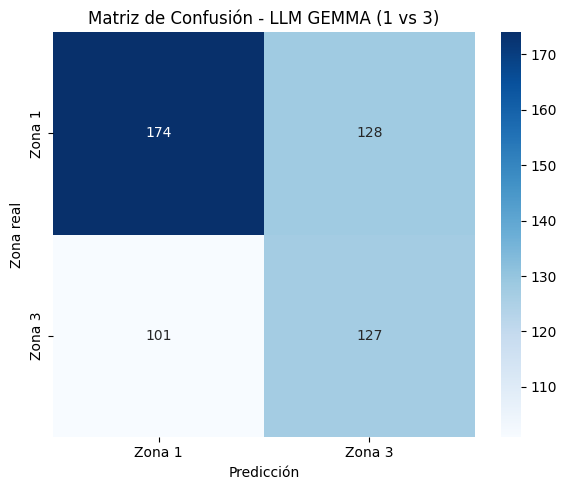

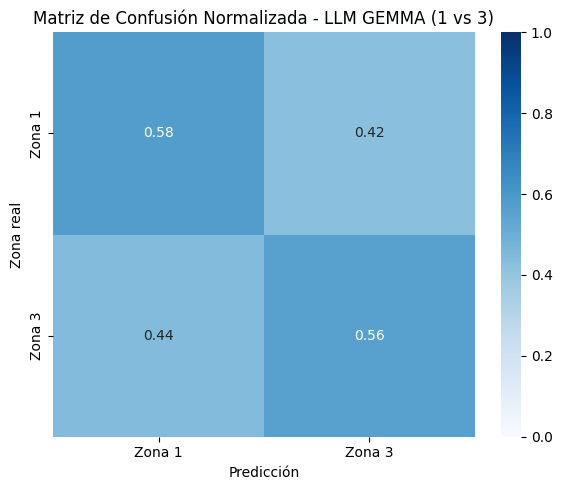

In [ ]:
evaluador = EvaluadorResultadosBinario()
evaluador.evaluar("predicciones_finales_gemma_prueba1.csv", "GEMMA")

RESULTADOS CON LLAMA


 EVALUACION BINARIA (ZONAS 1 Y 3) - LLAMA 
Muestras evaluadas:           533
Accuracy:                     48.22%
Balanced accuracy:            51.75%
Precision macro:              52.28%
Recall macro:                 51.75%
F1 macro:                     46.52%
F1 weighted:                  45.18%

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             CRUZADO                  1     True
  v1_p2_diag     derecha          1             ABIERTO                  3    False
  v1_p4_diag     derecha          3             CRUZADO                  1    False
  v1_p5_diag     derecha          1             CRUZADO                  1     True
  v1_p6_diag     derecha          1             CRUZADO                  1     True
  v1_p7_diag     derecha          3             ABIERTO                  3     True
  v1_p8_diag   izquierda          1             ABIERTO                 

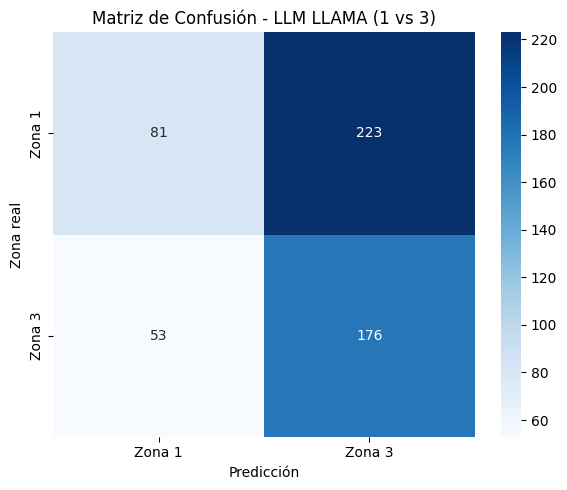

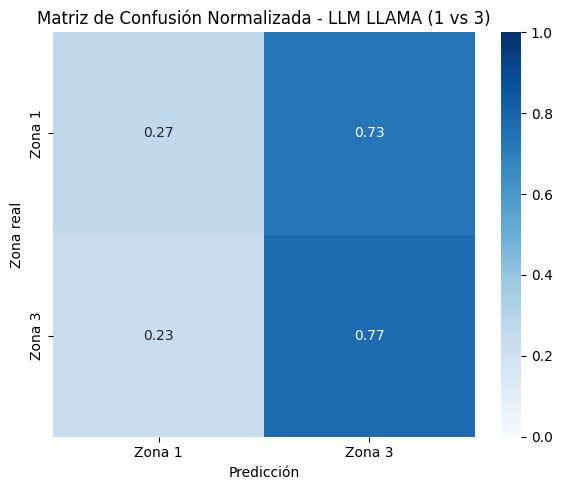

In [ ]:
evaluador = EvaluadorResultadosBinario()
evaluador.evaluar("predicciones_finales_prueba1_llama.csv", "llama")

RESULTADOS CON QWEN 3.5


 EVALUACION BINARIA (ZONAS 1 Y 3) - QWEN 3.5 
Muestras evaluadas:           533
Accuracy:                     49.91%
Balanced accuracy:            51.67%
Precision macro:              51.74%
Recall macro:                 51.67%
F1 macro:                     49.77%
F1 weighted:                  49.40%

Resumen detallado de las predicciones:
      vid_ID kicker_foot  zona_real prediccion_etiqueta  prediccion_numero  acierto
  v1_p1_diag     derecha          1             ABIERTO                  3    False
  v1_p2_diag     derecha          1             ABIERTO                  3    False
  v1_p4_diag     derecha          3             ABIERTO                  3     True
  v1_p5_diag     derecha          1             CRUZADO                  1     True
  v1_p6_diag     derecha          1             CRUZADO                  1     True
  v1_p7_diag     derecha          3             ABIERTO                  3     True
  v1_p8_diag   izquierda          1             ABIERTO              

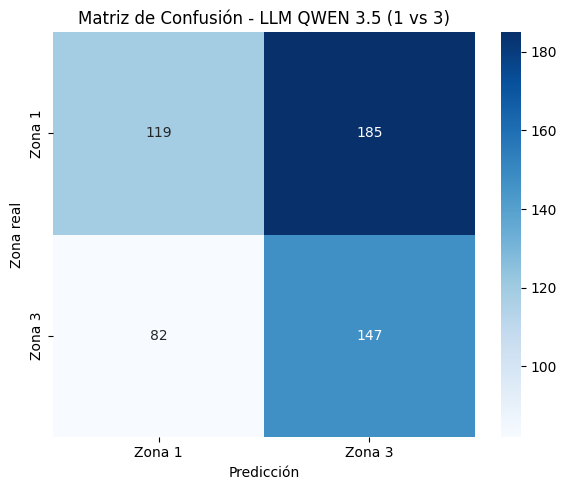

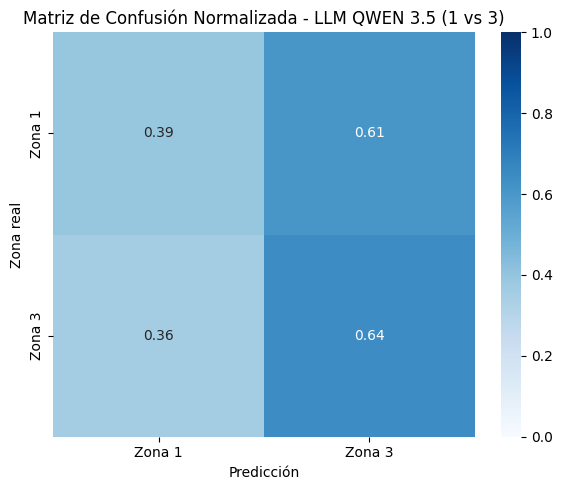

In [ ]:
evaluador = EvaluadorResultadosBinario()
evaluador.evaluar("predicciones_finales_qwen3.5.csv", "qwen 3.5")

### 9. Generación Estructurada de la Memoria Visual: Variante Podada

Este bloque de código representa la implementación técnica de la versión podada (v2) del *prompt* dirigido al modelo de visión multimodal. Tras analizar los primeros resultados de la calidad observacional, se planteó la hipótesis de que ciertas variables biomecánicas actuaban como ruido estadístico. La suposición era que algunos de estos atributos resultaban demasiado difíciles de observar de forma consistente en los fotogramas o simplemente carecían de una señal direccional clara, lo que terminaba introduciendo entropía y confundiendo a los clasificadores posteriores.

Para validar esta hipótesis empíricamente, se diseñó este nuevo *script*. Aunque mantiene intacta la arquitectura de extracción probabilística basada en JSON (exigiendo valor, confianza, evidencia y visibilidad), aplica una severa reducción de dimensionalidad directamente en la fase de inferencia visual. Se eliminaron de raíz las variables consideradas menos informativas o más propensas a errores de percepción, tales como la postura del torso y el balanceo de los brazos durante la carrera inicial, así como la flexión de la pierna de apoyo y el indicador de visibilidad del balón en el momento del impacto. Además de esta supresión de características, el espacio categórico de las variables supervivientes fue simplificado y condensado en descriptores más asertivos para limitar el margen de dispersión semántica de la red neuronal.

Acorde con esta restricción estructural, se ajustaron los hiperparámetros del motor de inferencia, reduciendo la temperatura de 0.2 a 0.1 para forzar un comportamiento mucho más determinista y conservador en la asignación de etiquetas. La ejecución de esta variante generó un conjunto de datos paralelo que, al ser sometido al escrutinio del diagnóstico tabular, demostró que la poda era un arma de doble filo. Si bien esta limpieza del ruido aparente logró mejorar ligeramente el rendimiento de los modelos lineales más simples, destruyó de forma colateral las combinaciones sutiles de variables que algoritmos más profundos y complejos, como el Random Forest, necesitaban para alcanzar su máximo techo predictivo. En definitiva, la implementación de este bloque metodológico sirvió para constatar que, en el análisis biomecánico mediante modelos de visión, una representación artificialmente simplificada no siempre equivale a una representación más útil.

In [ ]:
import json
import re
import pandas as pd

def construir_memoria_estructurada_json(desc_carrera_1, desc_carrera_2, desc_impacto, desc_seguimiento):
    def parsear_json_seguro(texto, fase):
        if not texto:
            return {
                "fase": fase,
                "error": "respuesta_vacia"
            }

        texto = texto.strip()
        texto = re.sub(r"^```json\s*|\s*```$", "", texto, flags=re.IGNORECASE | re.MULTILINE).strip()

        try:
            return json.loads(texto)
        except Exception:
            return {
                "fase": fase,
                "error": "json_invalido",
                "texto_original": texto
            }

    return {
        "carrera_inicial": parsear_json_seguro(desc_carrera_1, "carrera_inicial"),
        "planta_apoyo": parsear_json_seguro(desc_carrera_2, "planta_apoyo"),
        "impacto": parsear_json_seguro(desc_impacto, "impacto"),
        "seguimiento": parsear_json_seguro(desc_seguimiento, "seguimiento")
    }


def generar_memoria_visual(video_path, vid_data, pierna):
    fases = extract_frames_by_phase(video_path, vid_data)
    if not fases:
        return None

    def llamar_vlm(frames_b64, prompt_sistema, prompt_usuario):
        if not frames_b64:
            return json.dumps({"error": "no_hay_frames"}, ensure_ascii=False)

        content = [{"type": "text", "text": prompt_usuario}]
        for img in frames_b64:
            content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{img}"}
            })

        try:
            response = CLIENT.chat.completions.create(
                model="local-model",
                messages=[
                    {"role": "system", "content": prompt_sistema},
                    {"role": "user", "content": content}
                ],
                max_tokens=900,
                temperature=0.1
            )
            return response.choices[0].message.content
        except Exception as e:
            return json.dumps({
                "error": f"error_visual: {str(e)}"
            }, ensure_ascii=False)

    pierna_golpeo = str(pierna).strip().lower()

    prompt_sistema_fase = f"""
Eres un extractor de evidencia visual para el análisis de penaltis.

Contexto:
- Pierna de golpeo del jugador: {pierna_golpeo}
- Cámara: diagonal trasera
- Tarea: describir SOLO evidencia visual observable en las imágenes

Reglas obligatorias:
1. NO debes predecir la dirección final del tiro.
2. NO debes usar conocimiento biomecánico para rellenar huecos.
3. Si algo no se ve con claridad, usa el valor "indeterminado".
4. Para cada atributo debes devolver:
   - "valor"
   - "confianza" entre 0.0 y 1.0
   - "evidencia" breve basada en píxeles/posición relativa
   - "visible" = true o false
5. Si hay blur, oclusión o perspectiva ambigua, indícalo en la evidencia.
6. NO uses expresiones como "lo típico", "probablemente", "consistente con".
7. Usa solo lo que se vea en la secuencia de esa fase.
8. Si una etiqueta no es directamente observable en la imagen, devuelve "indeterminado" con confianza <= 0.25.
9. Devuelve SOLO JSON válido.
""".strip()

    prompt_carrera_1 = """
Analiza la secuencia de carrera inicial.

Devuelve SOLO este JSON:

{
  "fase": "carrera_inicial",
  "direccion_aproximacion_en_imagen": {
    "valor": "izquierda|derecha|frontal|diagonal_izquierda|diagonal_derecha|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "trayectoria_centro_masa_aparente": {
    "valor": "frontal|diagonal_izquierda|diagonal_derecha|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "amplitud_zancada_aparente": {
    "valor": "corta|media|larga|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "calidad_visual": {
    "valor": "alta|media|baja",
    "confianza": 1.0,
    "evidencia": "",
    "visible": true
  }
}
""".strip()

    prompt_carrera_2 = """
Analiza la secuencia de planta/apoyo.

Devuelve SOLO este JSON:

{
  "fase": "planta_apoyo",
  "direccion_llegada_en_imagen": {
    "valor": "izquierda|derecha|frontal|diagonal_izquierda|diagonal_derecha|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "torso_aparente": {
    "valor": "erguido|ligeramente_inclinado|inclinado_adelante|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "pie_apoyo_altura_relativa_balon": {
    "valor": "retrasado|alineado|adelantado|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "pie_apoyo_orientacion_aparente": {
    "valor": "frontal_porteria|ligeramente_abierto|muy_abierto|hacia_izquierda_imagen|hacia_derecha_imagen|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "hombros_respecto_porteria_aparente": {
    "valor": "abiertos|semiabiertos|cerrados|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "calidad_visual": {
    "valor": "alta|media|baja",
    "confianza": 1.0,
    "evidencia": "",
    "visible": true
  }
}
""".strip()

    prompt_impacto = """
Analiza el frame o secuencia de impacto pie-balón.

Devuelve SOLO este JSON:

{
  "fase": "impacto",
  "torso_en_contacto": {
    "valor": "erguido|ligeramente_inclinado|inclinado_adelante|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "superficie_contacto_aparente": {
    "valor": "interior|empeine|puntera|exterior|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "pierna_golpeo_extension_aparente": {
    "valor": "flexionada|media_extension|muy_extendida|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "calidad_visual": {
    "valor": "alta|media|baja",
    "confianza": 1.0,
    "evidencia": "",
    "visible": true
  }
}
""".strip()

    prompt_seguimiento = """
Analiza SOLO la fase posterior al impacto.

Devuelve SOLO este JSON:

{
  "fase": "seguimiento",
  "direccion_pierna_golpeo_en_imagen": {
    "valor": "izquierda_imagen|derecha_imagen|arriba|diagonal_izquierda|diagonal_derecha|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "altura_pie_golpeo_final": {
    "valor": "por_debajo_cadera|a_altura_cadera|por_encima_cadera|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "giro_cuerpo_en_imagen": {
    "valor": "hacia_izquierda|hacia_derecha|poco_giro|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "apoyo_postimpacto_estabilidad": {
    "valor": "estable|inestable|indeterminado",
    "confianza": 0.0,
    "evidencia": "",
    "visible": true
  },
  "calidad_visual": {
    "valor": "alta|media|baja",
    "confianza": 1.0,
    "evidencia": "",
    "visible": true
  }
}
""".strip()

    desc_carrera_1 = llamar_vlm(fases["carrera_1"], prompt_sistema_fase, prompt_carrera_1)
    desc_carrera_2 = llamar_vlm(fases["carrera_2"], prompt_sistema_fase, prompt_carrera_2)
    desc_impacto = llamar_vlm(fases["impacto"], prompt_sistema_fase, prompt_impacto)
    desc_seguimiento = llamar_vlm(fases["seguimiento"], prompt_sistema_fase, prompt_seguimiento)

    memoria_json = construir_memoria_estructurada_json(
        desc_carrera_1,
        desc_carrera_2,
        desc_impacto,
        desc_seguimiento
    )

    return {
        "final": json.dumps(memoria_json, ensure_ascii=False, indent=2)
    }

### 10. Diagnóstico Supervisado de la Memoria Visual: Evaluación de la Variante Podada

Este bloque de código constituye la réplica exacta de la auditoría algorítmica desarrollada en la fase inicial de esta iteración, pero redirigida hacia la evaluación del conjunto de datos generado por el *prompt* podado (v2). Para garantizar la validez metodológica del experimento y aislar el impacto real de la reducción de dimensionalidad, la arquitectura de validación cruzada estratificada y el conducto de modelado clásico —que enfrenta a la Regresión Logística contra el Random Forest— se han conservado inalterados, sometiendo la nueva memoria visual exactamente al mismo escrutinio estadístico que su predecesora.

La única y fundamental diferencia técnica de esta celda respecto a la original reside en la reconfiguración del diccionario de mapeo interno de variables. El algoritmo de aplanamiento de datos ha sido actualizado para reflejar la estructura de la memoria podada, eliminando del rastreo las características biomecánicas que fueron suprimidas en el motor de visión. En concreto, el analizador ya no busca ni procesa la postura del torso o el balanceo de los brazos durante la carrera inicial, de igual manera que omite la flexión de la pierna de apoyo y la visibilidad del balón durante la fase de impacto, focalizando toda la vectorización y el entrenamiento en los atributos supervivientes.

La ejecución paralela de esta infraestructura de diagnóstico sobre la memoria v2 es lo que proporcionó la evidencia empírica definitiva para las conclusiones de la iteración. Al cruzar los registros de salida de ambas celdas, el sistema permitió constatar matemáticamente cómo la ausencia de estas variables aparentemente ruidosas propició una leve mejora en la exactitud balanceada de las configuraciones lineales más simples, pero castigó severamente el rendimiento del Random Forest en el escenario binario, demostrando que la poda de la matriz visual destruyó patrones combinados latentes que resultaban vitales para la máxima discriminación espacial.

In [ ]:
import json
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# =========================
# CONFIG
# =========================
INPUT_MEMORIAS_CSV = "memorias_visuales.csv"
INPUT_LABELS_CSV = "labeled_frames_grouped.csv"
OUTPUT_DIR = "."

ID_COL = "vid_ID"
FOOT_COL = "kicker_foot"
TARGET_COL = "zona_real"
TARGET_SOURCE_COL = "shoot_zone_grouped"
MEMORY_COLS = ["final", "memoria_generada"]

RANDOM_STATE = 42
N_SPLITS = 5

PHASE_ATTRS = {
    "carrera_inicial": [
        "direccion_aproximacion_en_imagen",
        "trayectoria_centro_masa_aparente",
        "amplitud_zancada_aparente",
    ],
    "planta_apoyo": [
        "direccion_llegada_en_imagen",
        "torso_aparente",
        "pie_apoyo_altura_relativa_balon",
        "pie_apoyo_orientacion_aparente",
        "hombros_respecto_porteria_aparente",
    ],
    "impacto": [
        "torso_en_contacto",
        "superficie_contacto_aparente",
        "pierna_golpeo_extension_aparente",
    ],
    "seguimiento": [
        "direccion_pierna_golpeo_en_imagen",
        "altura_pie_golpeo_final",
        "giro_cuerpo_en_imagen",
        "apoyo_postimpacto_estabilidad",
    ],
}
PHASES = list(PHASE_ATTRS.keys())


# =========================
# UTILS
# =========================
def parse_json_safe(texto):
    if pd.isna(texto):
        return None
    texto = re.sub(r"^```json\s*|\s*```$", "", str(texto).strip(), flags=re.I | re.M).strip()
    try:
        return json.loads(texto)
    except Exception:
        return None


def normalizar(x):
    if x is None:
        return "missing"
    x = str(x).strip().lower()
    return x if x else "missing"


def safe_float(x):
    try:
        return float(x)
    except Exception:
        return 0.0


def normalizar_target(x):
    try:
        return int(float(x))
    except Exception as e:
        raise ValueError(f"No pude convertir la zona real a entero: {x}") from e


def detectar_columna_memoria(df):
    for c in MEMORY_COLS:
        if c in df.columns:
            return c
    raise ValueError(f"No encuentro ninguna columna de memoria entre: {MEMORY_COLS}")


def cargar_y_unir_labels(df_mem, labels_csv):
    df_labels = pd.read_csv(labels_csv)[[ID_COL, TARGET_SOURCE_COL]].dropna().copy()

    inconsist = (
        df_labels.groupby(ID_COL)[TARGET_SOURCE_COL]
        .nunique()
        .reset_index(name="n")
        .query("n > 1")
    )
    if not inconsist.empty:
        bad = inconsist[ID_COL].astype(str).tolist()[:10]
        raise ValueError(f"Hay videos con más de una zona distinta. Ejemplos: {bad}")

    df_labels = (
        df_labels.drop_duplicates(subset=[ID_COL])
        .rename(columns={TARGET_SOURCE_COL: TARGET_COL})
        .copy()
    )
    df_labels[TARGET_COL] = df_labels[TARGET_COL].apply(normalizar_target)

    df = df_mem.merge(df_labels, on=ID_COL, how="inner")
    if df.empty:
        raise ValueError("El merge entre memorias y labels ha dado 0 filas.")

    n_missing = (~df_mem[ID_COL].isin(df_labels[ID_COL])).sum()
    if n_missing:
        print(f"Aviso: {n_missing} memorias no tenían label y se han descartado.")

    return df, df_labels


def extraer_attr(memoria, fase, atributo):
    pref = f"{fase}__{atributo}"
    bloque = (((memoria or {}).get(fase) or {}).get(atributo) if isinstance(memoria, dict) else None)
    if not isinstance(bloque, dict):
        return {f"{pref}__valor": "missing", f"{pref}__conf": 0.0, f"{pref}__visible": 0}
    return {
        f"{pref}__valor": normalizar(bloque.get("valor", "missing")),
        f"{pref}__conf": safe_float(bloque.get("confianza", 0.0)),
        f"{pref}__visible": int(bool(bloque.get("visible", False))),
    }


def extraer_calidad(memoria, fase):
    pref = f"{fase}__calidad_visual"
    bloque = (((memoria or {}).get(fase) or {}).get("calidad_visual") if isinstance(memoria, dict) else None)
    if not isinstance(bloque, dict):
        return {f"{pref}__valor": "missing", f"{pref}__conf": 0.0}
    return {
        f"{pref}__valor": normalizar(bloque.get("valor", "missing")),
        f"{pref}__conf": safe_float(bloque.get("confianza", 0.0)),
    }


def memoria_a_features(memoria):
    feats = {}
    for fase in PHASES:
        feats.update(extraer_calidad(memoria, fase))
        for attr in PHASE_ATTRS[fase]:
            feats.update(extraer_attr(memoria, fase, attr))
    return feats


def construir_grupos_atributos(columnas):
    grupos = defaultdict(list)
    for c in columnas:
        if c == FOOT_COL:
            continue
        m = re.match(r"^(carrera_inicial|planta_apoyo|impacto|seguimiento)__([^_].*?)__(valor|conf|visible)$", c)
        if m:
            grupos[f"{m.group(1)}__{m.group(2)}"].append(c)
            continue
        m = re.match(r"^(carrera_inicial|planta_apoyo|impacto|seguimiento)__calidad_visual__(valor|conf)$", c)
        if m:
            grupos[f"{m.group(1)}__calidad_visual"].append(c)
    return dict(grupos)


def resumen_metricas(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }


def tabla_metricas_por_clase(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    total = cm.sum()
    rows = []
    for i, cls in enumerate(labels):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        sens = tp / (tp + fn) if tp + fn else np.nan
        esp = tn / (tn + fp) if tn + fp else np.nan
        prec = tp / (tp + fp) if tp + fp else np.nan
        npv = tn / (tn + fn) if tn + fn else np.nan
        f1 = 2 * prec * sens / (prec + sens) if pd.notna(prec) and pd.notna(sens) and prec + sens else np.nan
        rows.append({
            "clase": cls,
            "soporte": int(cm[i, :].sum()),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "sensibilidad": sens,
            "especificidad": esp,
            "precision": prec,
            "npv": npv,
            "f1": f1,
        })
    return pd.DataFrame(rows)


def imprimir_tabla_metricas(nombre, dfm):
    print(nombre)
    print(dfm.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print()


# =========================
# CALIDAD OBSERVACIONAL
# =========================
def construir_calidad_observacional(df):
    rows = []
    for fase in PHASES:
        for attr in ["calidad_visual"] + PHASE_ATTRS[fase]:
            vals, confs, viss = [], [], []
            for mem in df["_memoria_json"]:
                if attr == "calidad_visual":
                    bloque = (((mem or {}).get(fase) or {}).get("calidad_visual") if isinstance(mem, dict) else None)
                    if isinstance(bloque, dict):
                        vals.append(normalizar(bloque.get("valor", "missing")))
                        confs.append(safe_float(bloque.get("confianza", 0.0)))
                    else:
                        vals.append("missing")
                        confs.append(0.0)
                    vis_rate = np.nan
                    tipo = "calidad_visual"
                else:
                    bloque = (((mem or {}).get(fase) or {}).get(attr) if isinstance(mem, dict) else None)
                    if isinstance(bloque, dict):
                        vals.append(normalizar(bloque.get("valor", "missing")))
                        confs.append(safe_float(bloque.get("confianza", 0.0)))
                        viss.append(int(bool(bloque.get("visible", False))))
                    else:
                        vals.append("missing")
                        confs.append(0.0)
                        viss.append(0)
                    vis_rate = float(np.mean(viss))
                    tipo = "atributo"

            s = pd.Series(vals)
            vc = s.value_counts(dropna=False)
            rows.append({
                "atributo": f"{fase}__{attr}",
                "fase": fase,
                "tipo": tipo,
                "n": len(s),
                "visible_rate": vis_rate,
                "indeterminado_rate": float((s == "indeterminado").mean()),
                "missing_rate": float((s == "missing").mean()),
                "mean_conf": float(np.mean(confs)),
                "n_unique_non_missing": int(
                    s[~s.isin(["missing", "indeterminado"] if attr != "calidad_visual" else ["missing"])].nunique()
                ),
                "most_common_value": vc.index[0] if len(vc) else "missing",
                "most_common_rate": float(vc.iloc[0] / len(s)) if len(s) else np.nan,
            })
    return pd.DataFrame(rows).sort_values(["fase", "atributo"]).reset_index(drop=True)


# =========================
# MODELADO
# =========================
def construir_pipeline(X, model_name):
    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    num_cols = [c for c in X.columns if c not in cat_cols]

    cat_tf = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    num_steps = [("imputer", SimpleImputer(strategy="constant", fill_value=0.0))]
    if model_name == "logreg":
        num_steps.append(("scaler", StandardScaler()))

    pre = ColumnTransformer([
        ("cat", cat_tf, cat_cols),
        ("num", Pipeline(num_steps), num_cols),
    ], remainder="drop")

    model = (
        LogisticRegression(
            solver="lbfgs",
            max_iter=4000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
        if model_name == "logreg"
        else RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )
    return Pipeline([("preprocessor", pre), ("model", model)])


def ejecutar_cv_con_ablacion(X, y, model_name):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    grupos = construir_grupos_atributos(X.columns)
    labels = sorted(pd.Series(y).dropna().unique().tolist())

    rows_baseline, rows_ab, rows_oof = [], [], []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_te = X.iloc[tr_idx].copy(), X.iloc[te_idx].copy()
        y_tr, y_te = y.iloc[tr_idx].copy(), y.iloc[te_idx].copy()

        pipe = construir_pipeline(X_tr, model_name)
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)

        metrics = resumen_metricas(y_te, pred)
        rows_baseline.append({"fold": fold, **metrics})
        rows_oof.append(pd.DataFrame({"fold": fold, "y_true": y_te.values, "y_pred": pred}))

        for atributo, cols_drop in grupos.items():
            keep_cols = [c for c in X.columns if c not in cols_drop]
            if not keep_cols:
                continue
            pipe_drop = construir_pipeline(X_tr[keep_cols], model_name)
            pipe_drop.fit(X_tr[keep_cols], y_tr)
            pred_drop = pipe_drop.predict(X_te[keep_cols])
            metrics_drop = resumen_metricas(y_te, pred_drop)
            rows_ab.append({
                "fold": fold,
                "atributo": atributo,
                "delta_accuracy": metrics["accuracy"] - metrics_drop["accuracy"],
                "delta_balanced_accuracy": metrics["balanced_accuracy"] - metrics_drop["balanced_accuracy"],
                "delta_f1_macro": metrics["f1_macro"] - metrics_drop["f1_macro"],
            })

    df_baseline = pd.DataFrame(rows_baseline)
    df_oof = pd.concat(rows_oof, ignore_index=True)
    df_ab = (
        pd.DataFrame(rows_ab)
        .groupby("atributo", as_index=False)
        .agg(
            n_folds=("fold", "count"),
            delta_accuracy_mean=("delta_accuracy", "mean"),
            delta_accuracy_std=("delta_accuracy", "std"),
            delta_balanced_accuracy_mean=("delta_balanced_accuracy", "mean"),
            delta_balanced_accuracy_std=("delta_balanced_accuracy", "std"),
            delta_f1_macro_mean=("delta_f1_macro", "mean"),
            delta_f1_macro_std=("delta_f1_macro", "std"),
        )
        .sort_values(["delta_balanced_accuracy_mean", "delta_f1_macro_mean"], ascending=False)
        .reset_index(drop=True)
    )

    return {
        "baseline": df_baseline,
        "ab_attr_resumen": df_ab,
        "metricas_clase": tabla_metricas_por_clase(df_oof["y_true"], df_oof["y_pred"], labels),
    }


def construir_X(df_feats, use_foot):
    drop_cols = [ID_COL, TARGET_COL] + ([] if use_foot else [FOOT_COL])
    return df_feats.drop(columns=drop_cols)


def renombrar_columnas_ablacion(df, prefix, task):
    return df.rename(columns={
        "n_folds": f"{prefix}_n_folds_{task}",
        "delta_accuracy_mean": f"{prefix}_delta_accuracy_mean_{task}",
        "delta_accuracy_std": f"{prefix}_delta_accuracy_std_{task}",
        "delta_balanced_accuracy_mean": f"{prefix}_delta_balanced_accuracy_mean_{task}",
        "delta_balanced_accuracy_std": f"{prefix}_delta_balanced_accuracy_std_{task}",
        "delta_f1_macro_mean": f"{prefix}_delta_f1_macro_mean_{task}",
        "delta_f1_macro_std": f"{prefix}_delta_f1_macro_std_{task}",
    })


def scenario_name(model_short, use_foot):
    return f"{model_short}_{'with_foot' if use_foot else 'no_foot'}"


# =========================
# MAIN
# =========================
def main():
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    df_mem = pd.read_csv(INPUT_MEMORIAS_CSV)
    req_mem = [ID_COL, FOOT_COL]
    miss = [c for c in req_mem if c not in df_mem.columns]
    if miss:
        raise ValueError(f"Faltan columnas en {INPUT_MEMORIAS_CSV}: {miss}")

    mem_col = detectar_columna_memoria(df_mem)
    df_mem["_memoria_json"] = df_mem[mem_col].apply(parse_json_safe)

    df, df_labels = cargar_y_unir_labels(df_mem, INPUT_LABELS_CSV)

    rows = []
    for _, r in df.iterrows():
        feats = memoria_a_features(r["_memoria_json"])
        feats[ID_COL] = r[ID_COL]
        feats[FOOT_COL] = normalizar(r[FOOT_COL])
        feats[TARGET_COL] = normalizar_target(r[TARGET_COL])
        rows.append(feats)

    df_feats = pd.DataFrame(rows)
    df_calidad = construir_calidad_observacional(df)

    print("=" * 78)
    print("DIAGNOSTICO DE ETIQUETAS: LOGREG VS RANDOM FOREST, CON Y SIN FOOT")
    print("=" * 78)
    print(f"Archivo de memorias: {INPUT_MEMORIAS_CSV}")
    print(f"Archivo de labels:   {INPUT_LABELS_CSV}")
    print(f"Videos con label unico: {len(df_labels)}")
    print(f"Muestras finales tras merge: {len(df)}")
    print()
    print(f"Memorias parseadas correctamente: {df['_memoria_json'].apply(lambda x: isinstance(x, dict)).mean():.2%}")

    ejemplo = next((x for x in df["_memoria_json"] if isinstance(x, dict)), None)
    if ejemplo is not None:
        print("\nClaves observadas en un ejemplo:")
        for fase in PHASES:
            claves = sorted(ejemplo.get(fase, {}).keys()) if isinstance(ejemplo.get(fase, {}), dict) else []
            print(f"  - {fase}: {claves}")
    print()

    y_multi = df_feats[TARGET_COL].astype(int)
    df_13 = df_feats[df_feats[TARGET_COL].isin([1, 3])].copy().reset_index(drop=True)
    if df_13.empty:
        raise ValueError("No hay muestras con zona_real en {1, 3}.")
    y_bin = df_13[TARGET_COL].astype(int)

    escenarios = [
        {"model_short": "lr", "model_name": "logreg", "use_foot": True},
        {"model_short": "lr", "model_name": "logreg", "use_foot": False},
        {"model_short": "rf", "model_name": "rf", "use_foot": True},
        {"model_short": "rf", "model_name": "rf", "use_foot": False},
    ]

    resultados, baseline_rows = {}, []

    for esc in escenarios:
        sc = scenario_name(esc["model_short"], esc["use_foot"])
        X_multi = construir_X(df_feats, esc["use_foot"])
        X_bin = construir_X(df_13, esc["use_foot"])

        res_multi = ejecutar_cv_con_ablacion(X_multi, y_multi, esc["model_name"])
        res_bin = ejecutar_cv_con_ablacion(X_bin, y_bin, esc["model_name"])
        resultados[(sc, "multiclase")] = res_multi
        resultados[(sc, "bin13")] = res_bin

        for tarea, res in [("multiclase", res_multi), ("bin13", res_bin)]:
            means = res["baseline"][["accuracy", "balanced_accuracy", "f1_macro"]].mean()
            baseline_rows.append({
                "escenario": sc,
                "modelo": esc["model_short"],
                "usa_kicker_foot": esc["use_foot"],
                "tarea": tarea,
                "accuracy_mean": means["accuracy"],
                "balanced_accuracy_mean": means["balanced_accuracy"],
                "f1_macro_mean": means["f1_macro"],
            })

        mm = res_multi["baseline"][["accuracy", "balanced_accuracy", "f1_macro"]].mean()
        mb = res_bin["baseline"][["accuracy", "balanced_accuracy", "f1_macro"]].mean()

        print(f"[{sc}] Multiclase")
        print(f"  Accuracy media CV:          {mm['accuracy']:.4f}")
        print(f"  Balanced accuracy media CV: {mm['balanced_accuracy']:.4f}")
        print(f"  F1 macro media CV:          {mm['f1_macro']:.4f}\n")
        print(f"Atributos {sc} multiclase:")
        print(
            res_multi["ab_attr_resumen"][["atributo", "delta_balanced_accuracy_mean", "delta_f1_macro_mean"]]
            .to_string(index=False, float_format=lambda x: f"{x:.6f}")
        )
        print()
        imprimir_tabla_metricas(f"Tabla por clase {sc} multiclase:", res_multi["metricas_clase"])

        print(f"[{sc}] Binario 1 vs 3")
        print(f"  Accuracy media CV:          {mb['accuracy']:.4f}")
        print(f"  Balanced accuracy media CV: {mb['balanced_accuracy']:.4f}")
        print(f"  F1 macro media CV:          {mb['f1_macro']:.4f}\n")
        print(f"Atributos {sc} bin13:")
        print(
            res_bin["ab_attr_resumen"][["atributo", "delta_balanced_accuracy_mean", "delta_f1_macro_mean"]]
            .to_string(index=False, float_format=lambda x: f"{x:.6f}")
        )
        print()
        imprimir_tabla_metricas(f"Tabla por clase {sc} bin13:", res_bin["metricas_clase"])
        print("-" * 78)

    df_baseline = pd.DataFrame(baseline_rows)
    df_baseline.to_csv(out_dir / "comparativa_modelos_baseline_con_y_sin_foot.csv", index=False, encoding="utf-8-sig")

    df_metricas_clase = pd.concat([
        resultados[(scenario_name(esc["model_short"], esc["use_foot"]), tarea)]["metricas_clase"].assign(
            escenario=scenario_name(esc["model_short"], esc["use_foot"]),
            modelo=esc["model_short"],
            usa_kicker_foot=esc["use_foot"],
            tarea=tarea
        )
        for esc in escenarios for tarea in ["multiclase", "bin13"]
    ], ignore_index=True)
    df_metricas_clase.to_csv(out_dir / "comparativa_metricas_por_clase_con_y_sin_foot.csv", index=False, encoding="utf-8-sig")

    df_final = df_calidad.copy()
    for esc in escenarios:
        sc = scenario_name(esc["model_short"], esc["use_foot"])
        for tarea in ["multiclase", "bin13"]:
            df_final = df_final.merge(
                renombrar_columnas_ablacion(resultados[(sc, tarea)]["ab_attr_resumen"].copy(), sc, tarea),
                on="atributo",
                how="left",
            )

    df_final.to_csv(out_dir / "diagnostico_atributos_con_y_sin_foot.csv", index=False, encoding="utf-8-sig")

    print("Top 12 atributos en el CSV final:")
    cols_show = [
        "atributo", "fase", "tipo", "visible_rate", "missing_rate", "indeterminado_rate",
        "lr_with_foot_delta_balanced_accuracy_mean_bin13",
        "lr_no_foot_delta_balanced_accuracy_mean_bin13",
        "rf_with_foot_delta_balanced_accuracy_mean_bin13",
        "rf_no_foot_delta_balanced_accuracy_mean_bin13",
    ]
    print(df_final[cols_show].head(12).to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print()
    print("Archivos generados:")
    print("  - comparativa_modelos_baseline_con_y_sin_foot.csv")
    print("  - comparativa_metricas_por_clase_con_y_sin_foot.csv")
    print("  - diagnostico_atributos_con_y_sin_foot.csv")


if __name__ == "__main__":
    main()

DIAGNOSTICO DE ETIQUETAS: LOGREG VS RANDOM FOREST, CON Y SIN FOOT
Archivo de memorias: memorias_visuales.csv
Archivo de labels:   labeled_frames_grouped.csv
Videos con label unico: 641
Muestras finales tras merge: 641

Memorias parseadas correctamente: 100.00%

Claves observadas en un ejemplo:
  - carrera_inicial: ['amplitud_zancada_aparente', 'calidad_visual', 'direccion_aproximacion_en_imagen', 'fase', 'trayectoria_centro_masa_aparente']
  - planta_apoyo: ['calidad_visual', 'direccion_llegada_en_imagen', 'fase', 'hombros_respecto_porteria_aparente', 'pie_apoyo_altura_relativa_balon', 'pie_apoyo_orientacion_aparente', 'torso_aparente']
  - impacto: ['calidad_visual', 'fase', 'pierna_golpeo_extension_aparente', 'superficie_contacto_aparente', 'torso_en_contacto']
  - seguimiento: ['altura_pie_golpeo_final', 'apoyo_postimpacto_estabilidad', 'calidad_visual', 'direccion_pierna_golpeo_en_imagen', 'fase', 'giro_cuerpo_en_imagen']

[lr_with_foot] Multiclase
  Accuracy media CV:          0.4